# Automated VWAP Execution Research

This notebook researches whether the VWAP Probability Band Engine can be converted into a rule-based execution layer.

The existing discretionary VWAP model remains unchanged.

This notebook is research-only. It does not send orders to MT5.

Current research objective:

- build a clean baseline automated continuation model
- test simple green reclaim / rejection setups
- simulate fixed Nasdaq-point execution
- apply daily risk controls
- compare filters across datasets
- choose a candidate Base V1 before creating a separate usable automation notebook

## Notebook Contents

| Section | Purpose | Main Output |
|---|---|---|
| 1. Setup & Configuration | Imports, paths, and automation settings | `AUTO_CONFIG` |
| 2. Raw OHLC Data Loading | Load MT5 candle CSVs | `raw_ohlc_df` |
| 3. Existing VWAP Engine Integration | Use the existing model to compute VWAP/bands | `engine_df` |
| 4. Automation Feature Engineering | Add shift, acceptance, chop, extension, and trend context features | `features_df` |
| 5. Simple Green Signal Detection | Detect long green reclaim and short green rejection setups | `signals_df` |
| 6. Fixed-Point Trade Simulation | Simulate SL, TP, BE, and one-trade-at-a-time logic | `trade_log` |
| 7. Daily Risk Controls | Add daily stop rules and skipped-signal logging | `controlled_trade_log` |
| 8. Trade Diagnostics | Analyse performance by side, time, body, extension, and shift strength | `diagnostic_trade_log` |
| 9. Strategy Filter Comparison | Compare strategy variants on the current dataset | `variant_comparison` |
| 10. Multi-Dataset Strategy Comparison | Compare variants across 30d and 1y CSV files | `multi_dataset_variant_results` |
| 11. Candidate V1 Decision Summary | Summarise findings and prepare for V1 automation notebook | Pending |

# 1. Setup & Configuration

This section prepares the notebook environment.

It defines:

- project paths
- data/artifact folders
- notebook display settings
- automation configuration
- fixed-point execution settings

No model logic is changed here.

In [285]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def find_project_root(start_path: Path | None = None) -> Path:
    """
    Find the project root by walking upward until a .git folder is found.
    Falls back to the current working directory if .git is not found.
    """
    if start_path is None:
        start_path = Path.cwd()

    start_path = start_path.resolve()

    for path in [start_path, *start_path.parents]:
        if (path / ".git").exists():
            return path

    return start_path


PROJECT_ROOT = find_project_root()

DATA_DIR = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
LIVE_ARTIFACTS_DIR = PROJECT_ROOT / "live_artifacts"

print("Current working directory:", Path.cwd())
print("Detected project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Current working directory: c:\GitHub Projects\VWAP-probability-band-engine\notebooks
Detected project root: C:\GitHub Projects\VWAP-probability-band-engine
Data directory: C:\GitHub Projects\VWAP-probability-band-engine\data


## Automation Configuration

This config controls only the execution-research layer.

It does not alter:

- VWAP calculation
- sigma-band calculation
- probability calibration
- signal-generation internals
- live MT5 overlay behaviour
- existing discretionary workflow

In [286]:
AUTO_CONFIG = {
    # Notebook mode
    "mode": "fully_automated_research",
    "research_only": True,

    # Scope
    "continuation_only": True,
    "allow_longs": True,
    "allow_shorts": True,
    "allow_reversals": False,
    "allow_b_tier": False,
    "allow_fresh_orange_entries": False,
    "allow_fresh_red_entries": False,

    # Setup tiers
    "s_tier_score": 5,
    "a_tier_score": 4,
    "minimum_tradeable_score": 4,

    # Execution
    "entry_mode": "next_bar_open",
    "one_trade_at_a_time": True,

    # Fixed Nasdaq point model
    # Distances are positive in config.
    # PnL result is signed later: SL = -29, TP = +58, BE = 0.
    "stop_loss_points": 29.0,
    "take_profit_points": 58.0,
    "breakeven_trigger_points": 29.0,

    # Risk controls
    "risk_per_trade_pct": 1.0,
    "max_consecutive_losses": 2,
    "daily_profit_cap_pct": 8.0,

    # Session controls
    "session_timezone": "Europe/London",
    "session_start": "14:00",
    "no_new_trades_after": "19:00",

    # Candle quality filters
    "min_body_ratio": 0.25,
    "min_close_through_green": 1.0,
    "max_extension_from_green": 8.0,

    # Shift / trend context
    "shift_lookback": 3,
    "vwap_cross_lookback": 8,
    "max_vwap_crosses_before_chop": 2,
}

AUTO_CONFIG

{'mode': 'fully_automated_research',
 'research_only': True,
 'continuation_only': True,
 'allow_longs': True,
 'allow_shorts': True,
 'allow_reversals': False,
 'allow_b_tier': False,
 'allow_fresh_orange_entries': False,
 'allow_fresh_red_entries': False,
 's_tier_score': 5,
 'a_tier_score': 4,
 'minimum_tradeable_score': 4,
 'entry_mode': 'next_bar_open',
 'one_trade_at_a_time': True,
 'stop_loss_points': 29.0,
 'take_profit_points': 58.0,
 'breakeven_trigger_points': 29.0,
 'risk_per_trade_pct': 1.0,
 'max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'session_timezone': 'Europe/London',
 'session_start': '14:00',
 'no_new_trades_after': '19:00',
 'min_body_ratio': 0.25,
 'min_close_through_green': 1.0,
 'max_extension_from_green': 8.0,
 'shift_lookback': 3,
 'vwap_cross_lookback': 8,
 'max_vwap_crosses_before_chop': 2}

## Execution Sign Convention

The config stores point distances as positive numbers.

For trade PnL:

- stop loss = `-29`
- breakeven = `0`
- take profit = `+58`

For price levels:

Long trade:

- stop = entry - 29
- breakeven trigger = entry + 29
- target = entry + 58

Short trade:

- stop = entry + 29
- breakeven trigger = entry - 29
- target = entry - 58

In [287]:
def build_trade_levels(entry_price: float, side: str, config: dict) -> dict:
    """
    Build fixed-point Nasdaq execution levels.

    Parameters
    ----------
    entry_price:
        Trade entry price.
    side:
        'long' or 'short'.
    config:
        AUTO_CONFIG dictionary.

    Returns
    -------
    dict
        Stop, breakeven trigger, and target prices.
    """
    side = side.lower()

    sl = config["stop_loss_points"]
    tp = config["take_profit_points"]
    be = config["breakeven_trigger_points"]

    if side == "long":
        return {
            "side": "long",
            "entry_price": entry_price,
            "stop_price": entry_price - sl,
            "breakeven_trigger_price": entry_price + be,
            "target_price": entry_price + tp,
        }

    if side == "short":
        return {
            "side": "short",
            "entry_price": entry_price,
            "stop_price": entry_price + sl,
            "breakeven_trigger_price": entry_price - be,
            "target_price": entry_price - tp,
        }

    raise ValueError("side must be 'long' or 'short'")

In [288]:
# Quick sanity check

long_example = build_trade_levels(entry_price=20000.0, side="long", config=AUTO_CONFIG)
short_example = build_trade_levels(entry_price=20000.0, side="short", config=AUTO_CONFIG)

pd.DataFrame([long_example, short_example])

,side,entry_price,stop_price,breakeven_trigger_price,target_price
0,long,20000.0,19971.0,20029.0,20058.0
1,short,20000.0,20029.0,19971.0,19942.0


# 2. Raw OHLC Data Loading

This section loads raw MT5 OHLC candle data.

The raw CSVs contain:

- datetime
- open
- high
- low
- close
- tick volume
- spread
- real volume

At this stage, VWAP and probability bands have not yet been computed.

In [289]:
REQUIRED_RAW_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
]

REQUIRED_ENGINE_OUTPUT_COLUMNS = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
]

COLUMN_ALIASES = {
    "datetime": ["datetime", "time", "timestamp", "date", "Date", "Time", "Datetime"],
    "open": ["open", "Open", "OPEN"],
    "high": ["high", "High", "HIGH"],
    "low": ["low", "Low", "LOW"],
    "close": ["close", "Close", "CLOSE"],

    # Volume is useful later but not strictly required for execution rules
    "tick_volume": ["tick_volume", "volume", "Volume", "tickvol", "real_volume"],

    # VWAP/reference aliases
    "vwap": ["vwap", "VWAP", "reference", "ref", "reference_line"],

    # Upper bands
    "upper_green": [
        "upper_green", "upper_1", "upper_band_1", "band_1p", "band_1_plus",
        "band_1+", "1+", "z1_upper", "upper_sigma_1"
    ],
    "upper_orange": [
        "upper_orange", "upper_2", "upper_band_2", "band_2p", "band_2_plus",
        "band_2+", "2+", "z2_upper", "upper_sigma_2"
    ],
    "upper_red": [
        "upper_red", "upper_3", "upper_band_3", "band_3p", "band_3_plus",
        "band_3+", "3+", "z3_upper", "upper_sigma_3"
    ],

    # Lower bands
    "lower_green": [
        "lower_green", "lower_1", "lower_band_1", "band_1m", "band_1_minus",
        "band_1-", "1-", "z1_lower", "lower_sigma_1"
    ],
    "lower_orange": [
        "lower_orange", "lower_2", "lower_band_2", "band_2m", "band_2_minus",
        "band_2-", "2-", "z2_lower", "lower_sigma_2"
    ],
    "lower_red": [
        "lower_red", "lower_3", "lower_band_3", "band_3m", "band_3_minus",
        "band_3-", "3-", "z3_lower", "lower_sigma_3"
    ],
}

In [290]:
def find_column(df: pd.DataFrame, candidates: list[str]) -> str | None:
    """
    Return the first matching column from a list of candidate names.
    """
    existing = set(df.columns)

    for col in candidates:
        if col in existing:
            return col

    # Case-insensitive fallback
    lower_map = {str(col).lower(): col for col in df.columns}
    for col in candidates:
        if str(col).lower() in lower_map:
            return lower_map[str(col).lower()]

    return None


def normalise_vwap_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Rename common VWAP/band export column names into the standard names used
    by the automation layer.

    This function does not change model values.
    It only standardises column names.
    """
    out = df.copy()
    rename_map = {}

    for standard_name, aliases in COLUMN_ALIASES.items():
        matched_col = find_column(out, aliases)

        if matched_col is not None and matched_col != standard_name:
            rename_map[matched_col] = standard_name

    out = out.rename(columns=rename_map)

    return out

In [291]:
def validate_automation_columns(df: pd.DataFrame, required_columns: list[str] | None = None) -> None:
    """
    Validate that the DataFrame has the columns required for automated
    VWAP execution research.

    Raises
    ------
    ValueError
        If required columns are missing.
    """
    if required_columns is None:
        required_columns = REQUIRED_AUTOMATION_COLUMNS

    missing = [col for col in required_columns if col not in df.columns]

    if missing:
        raise ValueError(
            "Missing required automation columns: "
            + ", ".join(missing)
            + "\n\nAvailable columns:\n"
            + ", ".join(map(str, df.columns))
        )

    print("All required automation columns are present.")

In [292]:
def prepare_raw_ohlc_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare raw MT5 OHLC data for later VWAP engine processing.

    This validates only the raw market data columns.

    It does not calculate VWAP.
    It does not calculate probability bands.
    It does not change the existing model logic.
    """
    out = normalise_vwap_columns(df)

    validate_automation_columns(out, required_columns=REQUIRED_RAW_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = ["open", "high", "low", "close"]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    # Optional MT5 fields
    for optional_col in ["tick_volume", "spread", "real_volume"]:
        if optional_col in out.columns:
            out[optional_col] = pd.to_numeric(out[optional_col], errors="coerce")

    # Basic candle features for later commits
    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out

def prepare_automation_dataframe(df: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare an existing VWAP engine output DataFrame for automation research.

    This function expects VWAP and band columns to already exist.

    Use prepare_raw_ohlc_dataframe() for raw MT5 OHLC files.
    """
    out = normalise_vwap_columns(df)

    validate_automation_columns(out, required_columns=REQUIRED_ENGINE_OUTPUT_COLUMNS)

    out["datetime"] = pd.to_datetime(out["datetime"], errors="coerce")
    out = out.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    numeric_cols = [
        "open",
        "high",
        "low",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in numeric_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce")

    out = out.dropna(subset=numeric_cols).reset_index(drop=True)

    out["candle_range"] = out["high"] - out["low"]
    out["candle_body"] = (out["close"] - out["open"]).abs()
    out["body_ratio"] = np.where(
        out["candle_range"] > 0,
        out["candle_body"] / out["candle_range"],
        0.0,
    )

    return out

In [293]:
def list_candidate_data_files() -> list[Path]:
    """
    Recursively list likely CSV/Parquet files inside the project.

    This searches the whole repo so files are found even if they are not
    directly inside /data, /artifacts, or /live_artifacts.
    """
    patterns = ["*.csv", "*.parquet"]

    files = []
    for pattern in patterns:
        files.extend(PROJECT_ROOT.rglob(pattern))

    # Avoid common virtual environment/cache folders
    ignored_parts = {
        ".git",
        ".venv",
        "venv",
        "__pycache__",
        ".ipynb_checkpoints",
    }

    clean_files = [
        file for file in files
        if not any(part in ignored_parts for part in file.parts)
    ]

    return sorted(set(clean_files))


candidate_files = list_candidate_data_files()

print(f"Found {len(candidate_files)} candidate data files:")
for file in candidate_files[:50]:
    print(file.relative_to(PROJECT_ROOT))

Found 6 candidate data files:
artifacts\tables\backtest_results.parquet
artifacts\tables\prob_table_marginal.parquet
artifacts\tables\prob_table_trend.parquet
data\historical\US100_cash_M1_NY_session_1y.csv
data\historical\US100_cash_M1_NY_session_30d.csv
live_artifacts\exports\zone_probabilities.csv


## Optional: Load Existing Export

Use this section only when you have a CSV or Parquet file that already contains the VWAP/band output.

For now, this notebook does not generate new VWAP bands.  
It only prepares already-computed model output for automation research.

In [294]:
# Default test file for automation research.
# Start with 30d because it is faster while building the notebook.

PREFERRED_DATA_FILE = "US100_cash_M1_NY_session_30d.csv"

candidate_files = list_candidate_data_files()

matching_files = [
    file for file in candidate_files
    if file.name == PREFERRED_DATA_FILE
]

if not matching_files:
    print(f"Could not find {PREFERRED_DATA_FILE}.")
    print("Available candidate files:")
    for file in candidate_files:
        print(file.relative_to(PROJECT_ROOT))
else:
    DATA_FILE = matching_files[0]
    print(f"Using file: {DATA_FILE.relative_to(PROJECT_ROOT)}")

    if DATA_FILE.suffix.lower() == ".csv":
        raw_df = pd.read_csv(DATA_FILE)
    elif DATA_FILE.suffix.lower() == ".parquet":
        raw_df = pd.read_parquet(DATA_FILE)
    else:
        raise ValueError(f"Unsupported file type: {DATA_FILE.suffix}")

    print("Raw columns:")
    print(list(raw_df.columns))

    raw_ohlc_df = prepare_raw_ohlc_dataframe(raw_df)

    print(f"\nLoaded {len(raw_ohlc_df):,} raw OHLC rows from {DATA_FILE.relative_to(PROJECT_ROOT)}")
    display(raw_ohlc_df.head())

Using file: data\historical\US100_cash_M1_NY_session_30d.csv
Raw columns:
['datetime', 'open', 'high', 'low', 'close', 'tick_volume', 'spread', 'real_volume']
All required automation columns are present.

Loaded 6,728 raw OHLC rows from data\historical\US100_cash_M1_NY_session_30d.csv


,datetime,open,high,low,close,tick_volume,spread,real_volume,candle_range,candle_body,body_ratio
0,2026-01-29 15:22:00,26033.45,26035.15,26027.95,26034.55,261,190,0,7.2,1.1,0.152778
1,2026-01-29 15:23:00,26034.45,26037.55,26032.15,26034.25,234,190,0,5.4,0.2,0.037037
2,2026-01-29 15:24:00,26034.45,26040.05,26034.45,26040.05,234,190,0,5.6,5.6,1.000000
3,2026-01-29 15:25:00,26040.15,26044.45,26036.25,26044.25,277,190,0,8.2,4.1,0.500000
4,2026-01-29 15:26:00,26044.55,26046.65,26039.25,26045.25,228,190,0,7.4,0.7,0.094595


# 3. Existing VWAP Engine Integration

This section uses the existing VWAP Probability Band Engine modules to compute the model output.

It creates:

- reference / VWAP line
- sigma estimate
- upper and lower probability bands
- z-score
- zone classification

The purpose is to reuse the existing model logic without modifying the discretionary visual tool.

In [295]:
import sys
import importlib

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import src.config
importlib.reload(src.config)

from src.config import CONFIG
from src.reference import compute_reference
from src.sigma import compute_sigma, compute_bands
from src.zones import compute_zscore, classify_zones_series

print("Loaded existing VWAP engine modules.")
print(f"Reference type: {CONFIG['reference_type']}")
print(f"Vol method: {CONFIG['vol_method']}")
print(f"Zone thresholds: {CONFIG['zone_thresholds']}")

Loaded existing VWAP engine modules.
Reference type: VWAP
Vol method: ewma
Zone thresholds: [0.5, 1.0, 2.0]


In [296]:
def build_existing_engine_output(raw_ohlc_df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Build VWAP probability-band output from raw OHLC data using existing project logic.

    This function does not modify the model.
    It only calls the existing src functions and then adds automation-friendly aliases.
    """
    df = raw_ohlc_df.copy()

    # Required by existing reference calculation
    df["datetime"] = pd.to_datetime(df["datetime"], utc=True, errors="coerce")
    df = df.dropna(subset=["datetime"]).sort_values("datetime").reset_index(drop=True)

    if "tick_volume" not in df.columns:
        df["tick_volume"] = 1.0

    df["tick_volume"] = pd.to_numeric(df["tick_volume"], errors="coerce").fillna(1.0).clip(lower=1.0)

    df["typical_price"] = (df["high"] + df["low"] + df["close"]) / 3.0
    df["session_date"] = df["datetime"].dt.date

    # Existing model logic
    df["reference"] = compute_reference(df, config)
    df["price_deviation"] = df["close"] - df["reference"]

    df["sigma"] = compute_sigma(df, config)

    bands = compute_bands(df, df["sigma"])
    df = pd.concat([df, bands], axis=1)

    df["z_score"] = compute_zscore(df)
    df["zone"] = classify_zones_series(df["z_score"], config["zone_thresholds"])

    # Automation-friendly aliases
    df["vwap"] = df["reference"]

    df["upper_green"] = df["band_1p"]
    df["upper_orange"] = df["band_2p"]
    df["upper_red"] = df["band_3p"]

    df["lower_green"] = df["band_1n"]
    df["lower_orange"] = df["band_2n"]
    df["lower_red"] = df["band_3n"]

    # Keep candle features consistent
    df["candle_range"] = df["high"] - df["low"]
    df["candle_body"] = (df["close"] - df["open"]).abs()
    df["body_ratio"] = np.where(
        df["candle_range"] > 0,
        df["candle_body"] / df["candle_range"],
        0.0,
    )

    return df

In [297]:
engine_df = build_existing_engine_output(raw_ohlc_df, CONFIG)

print(f"Built existing engine output for {len(engine_df):,} rows.")

display_cols = [
    "datetime",
    "open",
    "high",
    "low",
    "close",
    "vwap",
    "sigma",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "z_score",
    "zone",
]

display(engine_df[display_cols].tail())

✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
Built existing engine output for 6,728 rows.


,datetime,open,high,low,close,vwap,sigma,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,z_score,zone
6723,2026-03-17 16:25:00+00:00,24785.45,24794.45,24781.55,24792.35,24643.601231,29.695952,24673.297183,24702.993135,24732.689088,24613.905278,24584.209326,24554.513374,5.009059,Z3+
6724,2026-03-17 16:26:00+00:00,24792.25,24792.55,24779.95,24782.25,24644.731992,30.005161,24674.737154,24704.742315,24734.747477,24614.726831,24584.721670,24554.716508,4.583145,Z3+
6725,2026-03-17 16:27:00+00:00,24781.95,24783.35,24771.25,24772.75,24645.856740,29.752823,24675.609563,24705.362386,24735.115209,24616.103917,24586.351094,24556.598271,4.264915,Z3+
6726,2026-03-17 16:28:00+00:00,24772.55,24775.05,24767.55,24775.05,24647.079114,29.509526,24676.588640,24706.098167,24735.607693,24617.569588,24588.060061,24558.550535,4.336596,Z3+
6727,2026-03-17 16:29:00+00:00,24774.85,24782.25,24767.05,24769.75,24648.240001,29.043532,24677.283533,24706.327065,24735.370598,24619.196468,24590.152936,24561.109404,4.183720,Z3+


In [298]:
automation_ready_df = prepare_automation_dataframe(engine_df)

print(f"Automation-ready DataFrame: {len(automation_ready_df):,} rows")
print("Required automation columns are now available.")

display(
    automation_ready_df[
        [
            "datetime",
            "close",
            "vwap",
            "upper_green",
            "upper_orange",
            "upper_red",
            "lower_green",
            "lower_orange",
            "lower_red",
            "body_ratio",
        ]
    ].tail()
)

All required automation columns are present.
Automation-ready DataFrame: 6,728 rows
Required automation columns are now available.


,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,body_ratio
6723,2026-03-17 16:25:00+00:00,24792.35,24643.601231,24673.297183,24702.993135,24732.689088,24613.905278,24584.209326,24554.513374,0.534884
6724,2026-03-17 16:26:00+00:00,24782.25,24644.731992,24674.737154,24704.742315,24734.747477,24614.726831,24584.721670,24554.716508,0.793651
6725,2026-03-17 16:27:00+00:00,24772.75,24645.856740,24675.609563,24705.362386,24735.115209,24616.103917,24586.351094,24556.598271,0.760331
6726,2026-03-17 16:28:00+00:00,24775.05,24647.079114,24676.588640,24706.098167,24735.607693,24617.569588,24588.060061,24558.550535,0.333333
6727,2026-03-17 16:29:00+00:00,24769.75,24648.240001,24677.283533,24706.327065,24735.370598,24619.196468,24590.152936,24561.109404,0.335526


# 4. Automation Feature Engineering

This section creates automation-only features from the existing VWAP engine output.

Features include:

- band shifts
- red-band shift strength
- VWAP acceptance
- green-zone acceptance
- VWAP cross count
- chop markers
- band compression markers
- trend-damage markers

These features are used for research and filtering only.

In [299]:
AUTO_CONFIG.update(
    {
        # Feature lookbacks
        "acceptance_lookback": 3,
        "trend_lane_lookback": 5,
        "trend_damage_lookback": 5,
        "compression_lookback": 5,
        "flat_vwap_lookback": 5,

        # Chop / compression settings
        "flat_vwap_threshold_points": 3.0,
        "min_band_expansion_points": 0.0,

        # Red-band shift strength buckets over shift_lookback
        "red_shift_minimum_points": 3.0,
        "red_shift_good_points": 5.0,
        "red_shift_strong_points": 7.0,
        "red_shift_very_strong_points": 10.0,
        "red_shift_extreme_points": 20.0,
        "red_shift_abnormal_points": 40.0,
    }
)

AUTO_CONFIG

{'mode': 'fully_automated_research',
 'research_only': True,
 'continuation_only': True,
 'allow_longs': True,
 'allow_shorts': True,
 'allow_reversals': False,
 'allow_b_tier': False,
 'allow_fresh_orange_entries': False,
 'allow_fresh_red_entries': False,
 's_tier_score': 5,
 'a_tier_score': 4,
 'minimum_tradeable_score': 4,
 'entry_mode': 'next_bar_open',
 'one_trade_at_a_time': True,
 'stop_loss_points': 29.0,
 'take_profit_points': 58.0,
 'breakeven_trigger_points': 29.0,
 'risk_per_trade_pct': 1.0,
 'max_consecutive_losses': 2,
 'daily_profit_cap_pct': 8.0,
 'session_timezone': 'Europe/London',
 'session_start': '14:00',
 'no_new_trades_after': '19:00',
 'min_body_ratio': 0.25,
 'min_close_through_green': 1.0,
 'max_extension_from_green': 8.0,
 'shift_lookback': 3,
 'vwap_cross_lookback': 8,
 'max_vwap_crosses_before_chop': 2,
 'acceptance_lookback': 3,
 'trend_lane_lookback': 5,
 'trend_damage_lookback': 5,
 'compression_lookback': 5,
 'flat_vwap_lookback': 5,
 'flat_vwap_thresh

In [300]:
def consecutive_true_count(condition: pd.Series) -> pd.Series:
    """
    Count consecutive True values.

    Example:
    False, True, True, False, True -> 0, 1, 2, 0, 1
    """
    condition = condition.fillna(False).astype(bool)

    counts = []
    current_count = 0

    for value in condition:
        if value:
            current_count += 1
        else:
            current_count = 0

        counts.append(current_count)

    return pd.Series(counts, index=condition.index)


def classify_red_shift_strength(value: float, config: dict) -> str:
    """
    Classify red-band shift strength in Nasdaq points.

    The input should be positive and already converted into trend-direction strength.
    """
    if pd.isna(value):
        return "unknown"

    if value < config["red_shift_minimum_points"]:
        return "weak"

    if value < config["red_shift_good_points"]:
        return "minimum"

    if value < config["red_shift_strong_points"]:
        return "good"

    if value < config["red_shift_very_strong_points"]:
        return "strong"

    if value < config["red_shift_extreme_points"]:
        return "very_strong"

    if value < config["red_shift_abnormal_points"]:
        return "extreme"

    return "abnormal_news_or_crash_regime"

In [301]:
def add_automation_features(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add automation-only derived features to an existing VWAP engine DataFrame.

    This function does not alter the existing model logic.
    It only derives extra research columns from already-computed VWAP/band output.
    """
    out = df.copy()
    out = out.sort_values("datetime").reset_index(drop=True)

    shift_lookback = config["shift_lookback"]
    acceptance_lookback = config["acceptance_lookback"]
    trend_lane_lookback = config["trend_lane_lookback"]
    trend_damage_lookback = config["trend_damage_lookback"]
    compression_lookback = config["compression_lookback"]
    flat_vwap_lookback = config["flat_vwap_lookback"]
    vwap_cross_lookback = config["vwap_cross_lookback"]

    # ------------------------------------------------------------------
    # Band shifts
    # ------------------------------------------------------------------
    shift_columns = [
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
    ]

    for col in shift_columns:
        out[f"{col}_shift"] = out[col] - out[col].shift(shift_lookback)

    # Directional red-band strength.
    # For bullish continuation, upper red shifting up is strength.
    # For bearish continuation, lower red shifting down is strength, so multiply by -1.
    out["bullish_red_shift_strength"] = out["upper_red_shift"]
    out["bearish_red_shift_strength"] = -out["lower_red_shift"]

    out["bullish_red_shift_label"] = out["bullish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    out["bearish_red_shift_label"] = out["bearish_red_shift_strength"].apply(
        lambda value: classify_red_shift_strength(value, config)
    )

    # ------------------------------------------------------------------
    # Band expansion / compression
    # ------------------------------------------------------------------
    out["green_band_width"] = out["upper_green"] - out["lower_green"]
    out["orange_band_width"] = out["upper_orange"] - out["lower_orange"]
    out["red_band_width"] = out["upper_red"] - out["lower_red"]

    out["green_band_width_change"] = out["green_band_width"] - out["green_band_width"].shift(compression_lookback)
    out["orange_band_width_change"] = out["orange_band_width"] - out["orange_band_width"].shift(compression_lookback)
    out["red_band_width_change"] = out["red_band_width"] - out["red_band_width"].shift(compression_lookback)

    out["bands_expanding"] = out["red_band_width_change"] > config["min_band_expansion_points"]
    out["bands_compressing"] = out["red_band_width_change"] < 0

    # Opposite-side expansion context.
    # Bullish trend quality improves when lower bands shift down/away while upper bands shift up.
    # Bearish trend quality improves when upper bands shift up/away while lower bands shift down.
    out["bullish_opposite_band_expansion"] = -out["lower_red_shift"]
    out["bearish_opposite_band_expansion"] = out["upper_red_shift"]

    # ------------------------------------------------------------------
    # VWAP acceptance
    # ------------------------------------------------------------------
    out["close_above_vwap"] = out["close"] > out["vwap"]
    out["close_below_vwap"] = out["close"] < out["vwap"]

    out["closes_above_vwap_count"] = (
        out["close_above_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["closes_below_vwap_count"] = (
        out["close_below_vwap"]
        .astype(int)
        .rolling(acceptance_lookback, min_periods=1)
        .sum()
    )

    out["accepted_above_vwap"] = out["closes_above_vwap_count"] >= 2
    out["accepted_below_vwap"] = out["closes_below_vwap_count"] >= 2

    # ------------------------------------------------------------------
    # Trend-lane acceptance
    # ------------------------------------------------------------------
    # Bullish lane = between upper green and upper orange.
    # Bearish lane = between lower orange and lower green.
    out["close_in_bullish_green_lane"] = (
        (out["close"] >= out["upper_green"])
        & (out["close"] <= out["upper_orange"])
    )

    out["close_in_bearish_green_lane"] = (
        (out["close"] <= out["lower_green"])
        & (out["close"] >= out["lower_orange"])
    )

    out["bullish_lane_close_count"] = (
        out["close_in_bullish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    out["bearish_lane_close_count"] = (
        out["close_in_bearish_green_lane"]
        .astype(int)
        .rolling(trend_lane_lookback, min_periods=1)
        .sum()
    )

    # ------------------------------------------------------------------
    # Trend damage / trend death
    # ------------------------------------------------------------------
    out["close_below_upper_green"] = out["close"] < out["upper_green"]
    out["close_above_lower_green"] = out["close"] > out["lower_green"]

    out["consecutive_closes_below_upper_green"] = consecutive_true_count(out["close_below_upper_green"])
    out["consecutive_closes_above_lower_green"] = consecutive_true_count(out["close_above_lower_green"])

    out["bullish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_below_upper_green"] >= trend_damage_lookback
    )

    out["bearish_trend_dead_by_green_loss"] = (
        out["consecutive_closes_above_lower_green"] >= trend_damage_lookback
    )

    # Second close back inside green after temporary loss.
    # Bullish: price was below/at upper green, then closes back above upper green for 2 candles.
    # Bearish: price was above/at lower green, then closes back below lower green for 2 candles.
    out["bullish_second_close_back_above_green"] = (
        (out["close"] > out["upper_green"])
        & (out["close"].shift(1) > out["upper_green"].shift(1))
        & (out["close"].shift(2) <= out["upper_green"].shift(2))
    )

    out["bearish_second_close_back_below_green"] = (
        (out["close"] < out["lower_green"])
        & (out["close"].shift(1) < out["lower_green"].shift(1))
        & (out["close"].shift(2) >= out["lower_green"].shift(2))
    )

    # ------------------------------------------------------------------
    # VWAP crossing / chop markers
    # ------------------------------------------------------------------
    out["vwap_side"] = np.where(
        out["close"] > out["vwap"],
        1,
        np.where(out["close"] < out["vwap"], -1, 0),
    )

    out["vwap_cross"] = (
        (out["vwap_side"] != out["vwap_side"].shift(1))
        & (out["vwap_side"] != 0)
        & (out["vwap_side"].shift(1) != 0)
    )

    out["vwap_cross_count"] = (
        out["vwap_cross"]
        .astype(int)
        .rolling(vwap_cross_lookback, min_periods=1)
        .sum()
    )

    out["vwap_shift_flat_check"] = out["vwap"] - out["vwap"].shift(flat_vwap_lookback)
    out["vwap_is_flat"] = out["vwap_shift_flat_check"].abs() <= config["flat_vwap_threshold_points"]

    out["possible_chop"] = (
        (out["vwap_cross_count"] >= config["max_vwap_crosses_before_chop"])
        & out["vwap_is_flat"]
    ) | (
        out["bands_compressing"]
        & out["vwap_is_flat"]
    )

    return out

In [302]:
features_df = add_automation_features(automation_ready_df, AUTO_CONFIG)

print(f"Feature DataFrame: {len(features_df):,} rows")
print(f"Columns added: {len(features_df.columns) - len(automation_ready_df.columns)}")

preview_cols = [
    "datetime",
    "close",
    "vwap",
    "upper_green",
    "upper_orange",
    "upper_red",
    "lower_green",
    "lower_orange",
    "lower_red",
    "vwap_shift",
    "upper_red_shift",
    "lower_red_shift",
    "bullish_red_shift_strength",
    "bearish_red_shift_strength",
    "bullish_red_shift_label",
    "bearish_red_shift_label",
    "accepted_above_vwap",
    "accepted_below_vwap",
    "bullish_lane_close_count",
    "bearish_lane_close_count",
    "vwap_cross_count",
    "bands_compressing",
    "possible_chop",
]

display(features_df[preview_cols].tail(20))

Feature DataFrame: 6,728 rows
Columns added: 45


,datetime,close,vwap,upper_green,upper_orange,upper_red,lower_green,lower_orange,lower_red,vwap_shift,upper_red_shift,lower_red_shift,bullish_red_shift_strength,bearish_red_shift_strength,bullish_red_shift_label,bearish_red_shift_label,accepted_above_vwap,accepted_below_vwap,bullish_lane_close_count,bearish_lane_close_count,vwap_cross_count,bands_compressing,possible_chop
6708,2026-03-17 16:10:00+00:00,24735.85,24631.606721,24652.463155,24673.319589,24694.176023,24610.750287,24589.893853,24569.037419,1.621496,4.686291,-1.443300,4.686291,1.443300,minimum,weak,True,False,0.0,0.0,0.0,False,False
6709,2026-03-17 16:11:00+00:00,24739.85,24632.045744,24653.375608,24674.705472,24696.035336,24610.715880,24589.386016,24568.056152,1.428797,5.051325,-2.193731,5.051325,2.193731,good,weak,True,False,0.0,0.0,0.0,False,False
6710,2026-03-17 16:12:00+00:00,24737.55,24632.506550,24654.044910,24675.583271,24697.121631,24610.968190,24589.429830,24567.891470,1.401198,4.517602,-1.715206,4.517602,1.715206,minimum,weak,True,False,0.0,0.0,0.0,False,False
6711,2026-03-17 16:13:00+00:00,24733.55,24632.982657,24654.452766,24675.922876,24697.392985,24611.512547,24590.042438,24568.572328,1.375935,3.216962,-0.465091,3.216962,0.465091,minimum,weak,True,False,0.0,0.0,0.0,False,False
6712,2026-03-17 16:14:00+00:00,24744.95,24633.523591,24655.438622,24677.353654,24699.268685,24611.608560,24589.693528,24567.778497,1.477847,3.233348,-0.277654,3.233348,0.277654,minimum,weak,True,False,0.0,0.0,0.0,False,False
6713,2026-03-17 16:15:00+00:00,24743.35,24634.119503,24656.250719,24678.381934,24700.513150,24611.988287,24589.857071,24567.725855,1.612953,3.391519,-0.165614,3.391519,0.165614,minimum,weak,True,False,0.0,0.0,0.0,False,False
6714,2026-03-17 16:16:00+00:00,24744.05,24634.641836,24656.924728,24679.207620,24701.490512,24612.358944,24590.076052,24567.793160,1.659179,4.097527,-0.779168,4.097527,0.779168,minimum,weak,True,False,0.0,0.0,0.0,False,False
6715,2026-03-17 16:17:00+00:00,24750.25,24635.340387,24658.003238,24680.666089,24703.328939,24612.677536,24590.014685,24567.351834,1.816796,4.060255,-0.426663,4.060255,0.426663,minimum,weak,True,False,0.0,0.0,0.0,False,False
6716,2026-03-17 16:18:00+00:00,24758.05,24636.084553,24659.460040,24682.835526,24706.211012,24612.709067,24589.333581,24565.958095,1.965051,5.697862,-1.767761,5.697862,1.767761,good,weak,True,False,0.0,0.0,0.0,False,False
6717,2026-03-17 16:19:00+00:00,24767.55,24636.916935,24661.455407,24685.993878,24710.532350,24612.378463,24587.839992,24563.301520,2.275099,9.041838,-4.491640,9.041838,4.491640,strong,minimum,True,False,0.0,0.0,0.0,False,False


In [303]:
summary = {
    "rows": len(features_df),
    "possible_chop_rows": int(features_df["possible_chop"].sum()),
    "accepted_above_vwap_rows": int(features_df["accepted_above_vwap"].sum()),
    "accepted_below_vwap_rows": int(features_df["accepted_below_vwap"].sum()),
    "bullish_second_close_back_above_green": int(features_df["bullish_second_close_back_above_green"].sum()),
    "bearish_second_close_back_below_green": int(features_df["bearish_second_close_back_below_green"].sum()),
    "bullish_trend_dead_by_green_loss": int(features_df["bullish_trend_dead_by_green_loss"].sum()),
    "bearish_trend_dead_by_green_loss": int(features_df["bearish_trend_dead_by_green_loss"].sum()),
}

pd.Series(summary)

rows                                     6728
possible_chop_rows                       3297
accepted_above_vwap_rows                 3289
accepted_below_vwap_rows                 3438
bullish_second_close_back_above_green     119
bearish_second_close_back_below_green     116
bullish_trend_dead_by_green_loss         4619
bearish_trend_dead_by_green_loss         4568
dtype: int64

This section only creates automation-derived context features.

It does not yet create:

- long signals
- short signals
- S/A/B setup classification
- entries
- stops
- take-profits
- breakeven logic
- trade logs

The next commit will use these features to build a continuation-state classifier:

- bullish continuation candidate
- bearish continuation candidate
- chop / unclear
- extension / stretched
- invalid / no trade

# 5. Simple Green Signal Detection

This section creates the first simple automated signal layer.

Current signal types:

- `LONG_GREEN_RECLAIM`
- `SHORT_GREEN_REJECTION`

This is the first MVP version of the automated continuation logic.

It does not yet include every discretionary filter.

In [304]:
def add_simple_green_signals(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Add simple MVP green reclaim / rejection signals.

    This is deliberately simple.

    It does not:
    - simulate trades
    - apply daily stop rules
    - apply breakeven logic
    - classify S/A/B setup tiers
    - place orders
    """
    out = df.copy()

    min_body_ratio = config["min_body_ratio"]
    min_close_through_green = config["min_close_through_green"]
    max_extension_from_green = config["max_extension_from_green"]

    # ------------------------------------------------------------
    # Long: upper-green reclaim
    # ------------------------------------------------------------
    out["long_touched_upper_green"] = out["low"] <= out["upper_green"]
    out["long_closed_above_upper_green"] = out["close"] > out["upper_green"]

    out["long_close_through_green_points"] = out["close"] - out["upper_green"]
    out["long_extension_from_green_points"] = out["close"] - out["upper_green"]

    out["long_close_through_green_valid"] = (
        out["long_close_through_green_points"] >= min_close_through_green
    )

    out["long_extension_valid"] = (
        out["long_extension_from_green_points"] <= max_extension_from_green
    )

    out["long_body_valid"] = out["body_ratio"] >= min_body_ratio

    out["long_not_orange_chase"] = out["close"] < out["upper_orange"]

    out["simple_long_green_reclaim"] = (
        out["accepted_above_vwap"]
        & (out["close"] > out["vwap"])
        & out["long_touched_upper_green"]
        & out["long_closed_above_upper_green"]
        & out["long_close_through_green_valid"]
        & out["long_extension_valid"]
        & out["long_body_valid"]
        & out["long_not_orange_chase"]
        & ~out["possible_chop"]
    )

    # ------------------------------------------------------------
    # Short: lower-green rejection
    # ------------------------------------------------------------
    out["short_touched_lower_green"] = out["high"] >= out["lower_green"]
    out["short_closed_below_lower_green"] = out["close"] < out["lower_green"]

    out["short_close_through_green_points"] = out["lower_green"] - out["close"]
    out["short_extension_from_green_points"] = out["lower_green"] - out["close"]

    out["short_close_through_green_valid"] = (
        out["short_close_through_green_points"] >= min_close_through_green
    )

    out["short_extension_valid"] = (
        out["short_extension_from_green_points"] <= max_extension_from_green
    )

    out["short_body_valid"] = out["body_ratio"] >= min_body_ratio

    out["short_not_orange_chase"] = out["close"] > out["lower_orange"]

    out["simple_short_green_rejection"] = (
        out["accepted_below_vwap"]
        & (out["close"] < out["vwap"])
        & out["short_touched_lower_green"]
        & out["short_closed_below_lower_green"]
        & out["short_close_through_green_valid"]
        & out["short_extension_valid"]
        & out["short_body_valid"]
        & out["short_not_orange_chase"]
        & ~out["possible_chop"]
    )

    # ------------------------------------------------------------
    # Combined signal label
    # ------------------------------------------------------------
    out["simple_signal_side"] = np.select(
        [
            out["simple_long_green_reclaim"],
            out["simple_short_green_rejection"],
        ],
        [
            "long",
            "short",
        ],
        default="none",
    )

    out["simple_signal_name"] = np.select(
        [
            out["simple_long_green_reclaim"],
            out["simple_short_green_rejection"],
        ],
        [
            "LONG_GREEN_RECLAIM",
            "SHORT_GREEN_REJECTION",
        ],
        default="NO_SIGNAL",
    )

    return out

In [305]:
signals_df = add_simple_green_signals(features_df, AUTO_CONFIG)

signal_counts = signals_df["simple_signal_name"].value_counts(dropna=False)
display(signal_counts)

signal_rows = signals_df[signals_df["simple_signal_name"] != "NO_SIGNAL"].copy()

print(f"Simple signals found: {len(signal_rows):,}")

display(
    signal_rows[
        [
            "datetime",
            "simple_signal_name",
            "simple_signal_side",
            "open",
            "high",
            "low",
            "close",
            "vwap",
            "upper_green",
            "upper_orange",
            "lower_green",
            "lower_orange",
            "body_ratio",
            "accepted_above_vwap",
            "accepted_below_vwap",
            "possible_chop",
            "long_close_through_green_points",
            "long_extension_from_green_points",
            "short_close_through_green_points",
            "short_extension_from_green_points",
        ]
    ].tail(50)
)

simple_signal_name
NO_SIGNAL                6615
SHORT_GREEN_REJECTION      61
LONG_GREEN_RECLAIM         52
Name: count, dtype: int64

Simple signals found: 113


,datetime,simple_signal_name,simple_signal_side,open,high,low,close,vwap,upper_green,upper_orange,lower_green,lower_orange,body_ratio,accepted_above_vwap,accepted_below_vwap,possible_chop,long_close_through_green_points,long_extension_from_green_points,short_close_through_green_points,short_extension_from_green_points
3867,2026-02-25 16:29:00+00:00,LONG_GREEN_RECLAIM,long,25105.05,25111.55,25097.85,25110.45,25091.442436,25105.921063,25120.399690,25076.963808,25062.485181,0.394161,True,False,False,4.528937,4.528937,-33.486192,-33.486192
4061,2026-02-26 16:23:00+00:00,SHORT_GREEN_REJECTION,short,25319.75,25320.75,25312.35,25314.45,25334.029800,25348.508427,25362.987055,25319.551172,25305.072545,0.630952,False,True,False,-34.058427,-34.058427,5.101172,5.101172
4314,2026-02-27 17:16:00+00:00,LONG_GREEN_RECLAIM,long,24913.53,24914.83,24897.73,24908.23,24848.594285,24900.524072,24952.453859,24796.664498,24744.734710,0.309942,True,False,False,7.705928,7.705928,-111.565502,-111.565502
4434,2026-03-02 15:56:00+00:00,SHORT_GREEN_REJECTION,short,24608.25,24609.55,24588.75,24589.25,24619.173089,24643.031682,24666.890275,24595.314496,24571.455903,0.913462,False,True,False,-53.781682,-53.781682,6.064496,6.064496
4437,2026-03-02 15:59:00+00:00,SHORT_GREEN_REJECTION,short,24556.05,24587.75,24556.05,24581.55,24617.615493,24647.642809,24677.670125,24587.588177,24557.560861,0.804416,False,True,False,-66.092809,-66.092809,6.038177,6.038177
4670,2026-03-03 16:32:00+00:00,LONG_GREEN_RECLAIM,long,24565.53,24569.63,24532.33,24537.83,24495.231046,24536.669409,24578.107773,24453.792683,24412.354320,0.742627,True,False,False,1.160591,1.160591,-84.037317,-84.037317
4701,2026-03-03 17:03:00+00:00,SHORT_GREEN_REJECTION,short,24438.23,24471.03,24435.83,24452.03,24498.589627,24540.284699,24581.979772,24456.894555,24415.199483,0.392045,False,True,False,-88.254699,-88.254699,4.864555,4.864555
4747,2026-03-04 14:29:00+00:00,SHORT_GREEN_REJECTION,short,24718.95,24719.65,24693.75,24696.05,24747.524288,24797.130860,24846.737431,24697.917716,24648.311145,0.884170,False,True,False,-101.080860,-101.080860,1.867716,1.867716
4748,2026-03-04 14:30:00+00:00,SHORT_GREEN_REJECTION,short,24697.55,24712.15,24691.75,24692.25,24744.790957,24793.318170,24841.845384,24696.263743,24647.736529,0.259804,False,True,False,-101.068170,-101.068170,4.013743,4.013743
4778,2026-03-04 15:00:00+00:00,LONG_GREEN_RECLAIM,long,24764.45,24779.75,24759.75,24776.75,24737.363022,24772.390591,24807.418159,24702.335453,24667.307884,0.615000,True,False,False,4.359409,4.359409,-74.414547,-74.414547


In [306]:
# Compact semi-automated style preview

signal_preview = signal_rows.copy()

signal_preview["entry_plan"] = "next_bar_open"
signal_preview["stop_points"] = -AUTO_CONFIG["stop_loss_points"]
signal_preview["breakeven_after_points"] = AUTO_CONFIG["breakeven_trigger_points"]
signal_preview["target_points"] = AUTO_CONFIG["take_profit_points"]

display(
    signal_preview[
        [
            "datetime",
            "simple_signal_name",
            "simple_signal_side",
            "entry_plan",
            "stop_points",
            "breakeven_after_points",
            "target_points",
            "close",
            "vwap",
            "body_ratio",
        ]
    ].tail(50)
)

,datetime,simple_signal_name,simple_signal_side,entry_plan,stop_points,breakeven_after_points,target_points,close,vwap,body_ratio
3867,2026-02-25 16:29:00+00:00,LONG_GREEN_RECLAIM,long,next_bar_open,-29.0,29.0,58.0,25110.45,25091.442436,0.394161
4061,2026-02-26 16:23:00+00:00,SHORT_GREEN_REJECTION,short,next_bar_open,-29.0,29.0,58.0,25314.45,25334.029800,0.630952
4314,2026-02-27 17:16:00+00:00,LONG_GREEN_RECLAIM,long,next_bar_open,-29.0,29.0,58.0,24908.23,24848.594285,0.309942
4434,2026-03-02 15:56:00+00:00,SHORT_GREEN_REJECTION,short,next_bar_open,-29.0,29.0,58.0,24589.25,24619.173089,0.913462
4437,2026-03-02 15:59:00+00:00,SHORT_GREEN_REJECTION,short,next_bar_open,-29.0,29.0,58.0,24581.55,24617.615493,0.804416
4670,2026-03-03 16:32:00+00:00,LONG_GREEN_RECLAIM,long,next_bar_open,-29.0,29.0,58.0,24537.83,24495.231046,0.742627
4701,2026-03-03 17:03:00+00:00,SHORT_GREEN_REJECTION,short,next_bar_open,-29.0,29.0,58.0,24452.03,24498.589627,0.392045
4747,2026-03-04 14:29:00+00:00,SHORT_GREEN_REJECTION,short,next_bar_open,-29.0,29.0,58.0,24696.05,24747.524288,0.884170
4748,2026-03-04 14:30:00+00:00,SHORT_GREEN_REJECTION,short,next_bar_open,-29.0,29.0,58.0,24692.25,24744.790957,0.259804
4778,2026-03-04 15:00:00+00:00,LONG_GREEN_RECLAIM,long,next_bar_open,-29.0,29.0,58.0,24776.75,24737.363022,0.615000


# 6. Fixed-Point Trade Simulation

This section turns simple signals into simulated trades.

Current execution assumptions:

- entry at next bar open
- stop loss = 29 Nasdaq points
- take profit = 58 Nasdaq points
- breakeven after +29 points
- one open trade at a time
- conservative intrabar ambiguity handling

In [307]:
def normalise_timestamp_to_session_time(timestamp, config: dict):
    """
    Convert timestamp to the configured session timezone.
    """
    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    return ts.tz_convert(config["session_timezone"])


def is_before_no_new_trades_cutoff(timestamp, config: dict) -> bool:
    """
    Check whether a new trade is allowed based on the configured cutoff time.
    """
    if "no_new_trades_after" not in config or config["no_new_trades_after"] is None:
        return True

    session_ts = normalise_timestamp_to_session_time(timestamp, config)

    cutoff = pd.to_datetime(config["no_new_trades_after"]).time()

    return session_ts.time() < cutoff

In [308]:
def simulate_single_trade(
    df: pd.DataFrame,
    entry_idx: int,
    signal_idx: int,
    side: str,
    signal_name: str,
    config: dict,
) -> dict:
    """
    Simulate one fixed-point trade from entry_idx onward.

    Uses conservative intrabar assumptions.
    """
    entry_row = df.iloc[entry_idx]
    signal_row = df.iloc[signal_idx]

    entry_price = float(entry_row["open"])
    levels = build_trade_levels(entry_price, side, config)

    stop_price = levels["stop_price"]
    be_trigger_price = levels["breakeven_trigger_price"]
    target_price = levels["target_price"]

    be_active = False

    for j in range(entry_idx, len(df)):
        row = df.iloc[j]

        high = float(row["high"])
        low = float(row["low"])

        if side == "long":
            if not be_active:
                original_sl_hit = low <= stop_price
                target_hit = high >= target_price
                be_hit = high >= be_trigger_price

                # Conservative ambiguity: SL first if both sides touch.
                if original_sl_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": stop_price,
                        "exit_reason": "SL",
                        "points_result": -config["stop_loss_points"],
                        "R_result": -1.0,
                        "bars_held": j - entry_idx + 1,
                    }

                if target_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": target_price,
                        "exit_reason": "TP",
                        "points_result": config["take_profit_points"],
                        "R_result": config["take_profit_points"] / config["stop_loss_points"],
                        "bars_held": j - entry_idx + 1,
                    }

                if be_hit:
                    be_active = True

                    # Conservative same-candle BE check.
                    if low <= entry_price:
                        return {
                            "signal_idx": signal_idx,
                            "entry_idx": entry_idx,
                            "exit_idx": j,
                            "signal_time": signal_row["datetime"],
                            "entry_time": entry_row["datetime"],
                            "exit_time": row["datetime"],
                            "side": side,
                            "signal_name": signal_name,
                            "entry_price": entry_price,
                            "stop_price_initial": stop_price,
                            "be_trigger_price": be_trigger_price,
                            "target_price": target_price,
                            "exit_price": entry_price,
                            "exit_reason": "BE",
                            "points_result": 0.0,
                            "R_result": 0.0,
                            "bars_held": j - entry_idx + 1,
                        }

            else:
                be_stop_hit = low <= entry_price
                target_hit = high >= target_price

                # Conservative ambiguity after BE: BE first.
                if be_stop_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": entry_price,
                        "exit_reason": "BE",
                        "points_result": 0.0,
                        "R_result": 0.0,
                        "bars_held": j - entry_idx + 1,
                    }

                if target_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": target_price,
                        "exit_reason": "TP",
                        "points_result": config["take_profit_points"],
                        "R_result": config["take_profit_points"] / config["stop_loss_points"],
                        "bars_held": j - entry_idx + 1,
                    }

        elif side == "short":
            if not be_active:
                original_sl_hit = high >= stop_price
                target_hit = low <= target_price
                be_hit = low <= be_trigger_price

                # Conservative ambiguity: SL first if both sides touch.
                if original_sl_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": stop_price,
                        "exit_reason": "SL",
                        "points_result": -config["stop_loss_points"],
                        "R_result": -1.0,
                        "bars_held": j - entry_idx + 1,
                    }

                if target_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": target_price,
                        "exit_reason": "TP",
                        "points_result": config["take_profit_points"],
                        "R_result": config["take_profit_points"] / config["stop_loss_points"],
                        "bars_held": j - entry_idx + 1,
                    }

                if be_hit:
                    be_active = True

                    # Conservative same-candle BE check.
                    if high >= entry_price:
                        return {
                            "signal_idx": signal_idx,
                            "entry_idx": entry_idx,
                            "exit_idx": j,
                            "signal_time": signal_row["datetime"],
                            "entry_time": entry_row["datetime"],
                            "exit_time": row["datetime"],
                            "side": side,
                            "signal_name": signal_name,
                            "entry_price": entry_price,
                            "stop_price_initial": stop_price,
                            "be_trigger_price": be_trigger_price,
                            "target_price": target_price,
                            "exit_price": entry_price,
                            "exit_reason": "BE",
                            "points_result": 0.0,
                            "R_result": 0.0,
                            "bars_held": j - entry_idx + 1,
                        }

            else:
                be_stop_hit = high >= entry_price
                target_hit = low <= target_price

                # Conservative ambiguity after BE: BE first.
                if be_stop_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": entry_price,
                        "exit_reason": "BE",
                        "points_result": 0.0,
                        "R_result": 0.0,
                        "bars_held": j - entry_idx + 1,
                    }

                if target_hit:
                    return {
                        "signal_idx": signal_idx,
                        "entry_idx": entry_idx,
                        "exit_idx": j,
                        "signal_time": signal_row["datetime"],
                        "entry_time": entry_row["datetime"],
                        "exit_time": row["datetime"],
                        "side": side,
                        "signal_name": signal_name,
                        "entry_price": entry_price,
                        "stop_price_initial": stop_price,
                        "be_trigger_price": be_trigger_price,
                        "target_price": target_price,
                        "exit_price": target_price,
                        "exit_reason": "TP",
                        "points_result": config["take_profit_points"],
                        "R_result": config["take_profit_points"] / config["stop_loss_points"],
                        "bars_held": j - entry_idx + 1,
                    }

        else:
            raise ValueError("side must be 'long' or 'short'")

    # Fallback if the trade never exits before data ends.
    final_row = df.iloc[-1]

    if side == "long":
        final_points = float(final_row["close"]) - entry_price
    else:
        final_points = entry_price - float(final_row["close"])

    return {
        "signal_idx": signal_idx,
        "entry_idx": entry_idx,
        "exit_idx": len(df) - 1,
        "signal_time": signal_row["datetime"],
        "entry_time": entry_row["datetime"],
        "exit_time": final_row["datetime"],
        "side": side,
        "signal_name": signal_name,
        "entry_price": entry_price,
        "stop_price_initial": stop_price,
        "be_trigger_price": be_trigger_price,
        "target_price": target_price,
        "exit_price": float(final_row["close"]),
        "exit_reason": "DATA_END",
        "points_result": final_points,
        "R_result": final_points / config["stop_loss_points"],
        "bars_held": len(df) - entry_idx,
    }

In [309]:
def simulate_fixed_point_trades(df: pd.DataFrame, config: dict) -> pd.DataFrame:
    """
    Simulate fixed-point trades from simple green signals.

    Entry is next bar open.
    Only one trade can be open at a time.
    """
    trades = []

    i = 0
    n = len(df)

    while i < n - 1:
        row = df.iloc[i]

        signal_name = row.get("simple_signal_name", "NO_SIGNAL")
        side = row.get("simple_signal_side", "none")

        if signal_name == "NO_SIGNAL" or side == "none":
            i += 1
            continue

        if not is_before_no_new_trades_cutoff(row["datetime"], config):
            i += 1
            continue

        entry_idx = i + 1

        trade = simulate_single_trade(
            df=df,
            entry_idx=entry_idx,
            signal_idx=i,
            side=side,
            signal_name=signal_name,
            config=config,
        )

        trades.append(trade)

        # Enforce one open trade at a time.
        i = trade["exit_idx"] + 1

    return pd.DataFrame(trades)

In [310]:
trade_log = simulate_fixed_point_trades(signals_df, AUTO_CONFIG)

print(f"Trades simulated: {len(trade_log):,}")

if len(trade_log) > 0:
    display(trade_log.tail(50))
else:
    print("No trades found.")

Trades simulated: 66


,signal_idx,entry_idx,exit_idx,signal_time,entry_time,exit_time,side,signal_name,entry_price,stop_price_initial,be_trigger_price,target_price,exit_price,exit_reason,points_result,R_result,bars_held
16,1896,1897,1899,2026-02-11 16:58:00+00:00,2026-02-11 16:59:00+00:00,2026-02-11 17:01:00+00:00,short,SHORT_GREEN_REJECTION,25211.13,25240.13,25182.13,25153.13,25240.13,SL,-29.0,-1.0,3
17,1901,1902,1908,2026-02-11 17:03:00+00:00,2026-02-11 17:04:00+00:00,2026-02-11 17:10:00+00:00,short,SHORT_GREEN_REJECTION,25203.13,25232.13,25174.13,25145.13,25145.13,TP,58.0,2.0,7
18,2015,2016,2029,2026-02-12 15:37:00+00:00,2026-02-12 15:38:00+00:00,2026-02-12 15:51:00+00:00,long,LONG_GREEN_RECLAIM,25301.25,25272.25,25330.25,25359.25,25301.25,BE,0.0,0.0,14
19,2067,2068,2071,2026-02-12 16:29:00+00:00,2026-02-12 16:30:00+00:00,2026-02-12 16:33:00+00:00,short,SHORT_GREEN_REJECTION,25265.35,25294.35,25236.35,25207.35,25294.35,SL,-29.0,-1.0,4
20,2196,2197,2201,2026-02-13 15:18:00+00:00,2026-02-13 15:19:00+00:00,2026-02-13 15:23:00+00:00,short,SHORT_GREEN_REJECTION,24580.55,24609.55,24551.55,24522.55,24609.55,SL,-29.0,-1.0,5
21,2215,2216,2223,2026-02-13 15:37:00+00:00,2026-02-13 15:38:00+00:00,2026-02-13 15:45:00+00:00,long,LONG_GREEN_RECLAIM,24681.65,24652.65,24710.65,24739.65,24681.65,BE,0.0,0.0,8
22,2437,2438,2452,2026-02-16 15:59:00+00:00,2026-02-16 16:00:00+00:00,2026-02-16 16:14:00+00:00,short,SHORT_GREEN_REJECTION,24775.85,24804.85,24746.85,24717.85,24717.85,TP,58.0,2.0,15
23,2499,2500,2524,2026-02-16 17:01:00+00:00,2026-02-16 17:02:00+00:00,2026-02-16 17:26:00+00:00,short,SHORT_GREEN_REJECTION,24707.03,24736.03,24678.03,24649.03,24649.03,TP,58.0,2.0,25
24,2549,2550,2584,2026-02-17 14:31:00+00:00,2026-02-17 14:32:00+00:00,2026-02-17 15:06:00+00:00,short,SHORT_GREEN_REJECTION,24537.05,24566.05,24508.05,24479.05,24479.05,TP,58.0,2.0,35
25,2705,2706,2709,2026-02-17 17:07:00+00:00,2026-02-17 17:08:00+00:00,2026-02-17 17:11:00+00:00,short,SHORT_GREEN_REJECTION,24452.83,24481.83,24423.83,24394.83,24452.83,BE,0.0,0.0,4


In [311]:
if len(trade_log) > 0:
    summary = {
        "total_trades": len(trade_log),
        "wins_TP": int((trade_log["exit_reason"] == "TP").sum()),
        "losses_SL": int((trade_log["exit_reason"] == "SL").sum()),
        "breakevens_BE": int((trade_log["exit_reason"] == "BE").sum()),
        "data_end": int((trade_log["exit_reason"] == "DATA_END").sum()),
        "total_points": trade_log["points_result"].sum(),
        "average_points": trade_log["points_result"].mean(),
        "total_R": trade_log["R_result"].sum(),
        "average_R": trade_log["R_result"].mean(),
        "win_rate_excluding_BE": (
            (trade_log["exit_reason"] == "TP").sum()
            / max(
                1,
                ((trade_log["exit_reason"] == "TP") | (trade_log["exit_reason"] == "SL")).sum(),
            )
        ),
        "average_bars_held": trade_log["bars_held"].mean(),
        "median_bars_held": trade_log["bars_held"].median(),
    }

    display(pd.Series(summary))

total_trades              66.000000
wins_TP                   19.000000
losses_SL                 21.000000
breakevens_BE             26.000000
data_end                   0.000000
total_points             493.000000
average_points             7.469697
total_R                   17.000000
average_R                  0.257576
win_rate_excluding_BE      0.475000
average_bars_held         14.833333
median_bars_held           9.500000
dtype: float64

In [312]:
if len(trade_log) > 0:
    exit_breakdown = trade_log["exit_reason"].value_counts(dropna=False)
    side_breakdown = trade_log["side"].value_counts(dropna=False)

    print("Exit breakdown:")
    display(exit_breakdown)

    print("Side breakdown:")
    display(side_breakdown)

Exit breakdown:


exit_reason
BE    26
SL    21
TP    19
Name: count, dtype: int64

Side breakdown:


side
short    36
long     30
Name: count, dtype: int64

In [313]:
if len(trade_log) > 0:
    trade_log["cumulative_points"] = trade_log["points_result"].cumsum()
    trade_log["cumulative_R"] = trade_log["R_result"].cumsum()

    display(
        trade_log[
            [
                "signal_time",
                "entry_time",
                "exit_time",
                "side",
                "signal_name",
                "entry_price",
                "exit_price",
                "exit_reason",
                "points_result",
                "R_result",
                "bars_held",
                "cumulative_points",
                "cumulative_R",
            ]
        ].tail(50)
    )

,signal_time,entry_time,exit_time,side,signal_name,entry_price,exit_price,exit_reason,points_result,R_result,bars_held,cumulative_points,cumulative_R
16,2026-02-11 16:58:00+00:00,2026-02-11 16:59:00+00:00,2026-02-11 17:01:00+00:00,short,SHORT_GREEN_REJECTION,25211.13,25240.13,SL,-29.0,-1.0,3,87.0,3.0
17,2026-02-11 17:03:00+00:00,2026-02-11 17:04:00+00:00,2026-02-11 17:10:00+00:00,short,SHORT_GREEN_REJECTION,25203.13,25145.13,TP,58.0,2.0,7,145.0,5.0
18,2026-02-12 15:37:00+00:00,2026-02-12 15:38:00+00:00,2026-02-12 15:51:00+00:00,long,LONG_GREEN_RECLAIM,25301.25,25301.25,BE,0.0,0.0,14,145.0,5.0
19,2026-02-12 16:29:00+00:00,2026-02-12 16:30:00+00:00,2026-02-12 16:33:00+00:00,short,SHORT_GREEN_REJECTION,25265.35,25294.35,SL,-29.0,-1.0,4,116.0,4.0
20,2026-02-13 15:18:00+00:00,2026-02-13 15:19:00+00:00,2026-02-13 15:23:00+00:00,short,SHORT_GREEN_REJECTION,24580.55,24609.55,SL,-29.0,-1.0,5,87.0,3.0
21,2026-02-13 15:37:00+00:00,2026-02-13 15:38:00+00:00,2026-02-13 15:45:00+00:00,long,LONG_GREEN_RECLAIM,24681.65,24681.65,BE,0.0,0.0,8,87.0,3.0
22,2026-02-16 15:59:00+00:00,2026-02-16 16:00:00+00:00,2026-02-16 16:14:00+00:00,short,SHORT_GREEN_REJECTION,24775.85,24717.85,TP,58.0,2.0,15,145.0,5.0
23,2026-02-16 17:01:00+00:00,2026-02-16 17:02:00+00:00,2026-02-16 17:26:00+00:00,short,SHORT_GREEN_REJECTION,24707.03,24649.03,TP,58.0,2.0,25,203.0,7.0
24,2026-02-17 14:31:00+00:00,2026-02-17 14:32:00+00:00,2026-02-17 15:06:00+00:00,short,SHORT_GREEN_REJECTION,24537.05,24479.05,TP,58.0,2.0,35,261.0,9.0
25,2026-02-17 17:07:00+00:00,2026-02-17 17:08:00+00:00,2026-02-17 17:11:00+00:00,short,SHORT_GREEN_REJECTION,24452.83,24452.83,BE,0.0,0.0,4,261.0,9.0


## Section 6 Notes

This commit adds the first fixed-point trade simulation.

Current simulation includes:

- next-bar-open entries
- 29-point stop
- 58-point target
- breakeven after +29 points
- one open trade at a time
- conservative intrabar ambiguity handling
- basic trade log and summary

Not added yet:

- daily stop after 2 consecutive losses
- daily +8% profit cap
- S/A setup tiering
- red-band shift score filters
- trend-death filters
- second-close re-entry logic
- failed-auction continuation logic

# 7. Daily Risk Controls

This section applies daily trading controls.

Rules:

- stop trading after 2 consecutive losses
- stop trading after +8% realised daily profit
- win resets consecutive losses
- loss increments consecutive losses
- breakeven is neutral
- no new trades after the configured session cutoff

In [314]:
def get_session_date(timestamp, config: dict):
    """
    Convert timestamp into the configured session timezone and return the date.
    """
    session_ts = normalise_timestamp_to_session_time(timestamp, config)
    return session_ts.date()


def trade_result_to_account_pct(trade: dict, config: dict) -> float:
    """
    Convert trade R-result into account percentage.

    If risk_per_trade_pct = 1:
    -1R = -1%
    +2R = +2%
    0R = 0%
    """
    return float(trade["R_result"]) * config["risk_per_trade_pct"]

In [315]:
def simulate_fixed_point_trades_with_daily_controls(
    df: pd.DataFrame,
    config: dict,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Simulate fixed-point trades with daily risk controls.

    Includes:
    - next-bar-open entries
    - 29-point stop
    - 58-point target
    - breakeven after +29 points
    - one open trade at a time
    - no new trades after configured cutoff
    - daily stop after max consecutive losses
    - daily stop after daily profit cap
    """
    trades = []
    skipped_signals = []

    current_session_date = None
    daily_realized_pct = 0.0
    consecutive_losses = 0

    i = 0
    n = len(df)

    while i < n - 1:
        row = df.iloc[i]

        signal_name = row.get("simple_signal_name", "NO_SIGNAL")
        side = row.get("simple_signal_side", "none")

        if signal_name == "NO_SIGNAL" or side == "none":
            i += 1
            continue

        signal_date = get_session_date(row["datetime"], config)

        # Reset daily counters when a new session date begins
        if signal_date != current_session_date:
            current_session_date = signal_date
            daily_realized_pct = 0.0
            consecutive_losses = 0

        # Session cutoff
        if not is_before_no_new_trades_cutoff(row["datetime"], config):
            skipped_signals.append(
                {
                    "signal_idx": i,
                    "signal_time": row["datetime"],
                    "session_date": signal_date,
                    "signal_name": signal_name,
                    "side": side,
                    "skip_reason": "SESSION_CUTOFF",
                    "daily_realized_pct": daily_realized_pct,
                    "consecutive_losses": consecutive_losses,
                }
            )
            i += 1
            continue

        # Daily consecutive-loss stop
        if consecutive_losses >= config["max_consecutive_losses"]:
            skipped_signals.append(
                {
                    "signal_idx": i,
                    "signal_time": row["datetime"],
                    "session_date": signal_date,
                    "signal_name": signal_name,
                    "side": side,
                    "skip_reason": "MAX_CONSECUTIVE_LOSSES",
                    "daily_realized_pct": daily_realized_pct,
                    "consecutive_losses": consecutive_losses,
                }
            )
            i += 1
            continue

        # Daily profit cap
        if daily_realized_pct >= config["daily_profit_cap_pct"]:
            skipped_signals.append(
                {
                    "signal_idx": i,
                    "signal_time": row["datetime"],
                    "session_date": signal_date,
                    "signal_name": signal_name,
                    "side": side,
                    "skip_reason": "DAILY_PROFIT_CAP",
                    "daily_realized_pct": daily_realized_pct,
                    "consecutive_losses": consecutive_losses,
                }
            )
            i += 1
            continue

        entry_idx = i + 1

        trade = simulate_single_trade(
            df=df,
            entry_idx=entry_idx,
            signal_idx=i,
            side=side,
            signal_name=signal_name,
            config=config,
        )

        trade_pct_result = trade_result_to_account_pct(trade, config)

        trade["session_date"] = signal_date
        trade["daily_realized_pct_before"] = daily_realized_pct
        trade["consecutive_losses_before"] = consecutive_losses
        trade["account_pct_result"] = trade_pct_result

        # Update daily realised PnL
        daily_realized_pct += trade_pct_result

        # Update consecutive-loss counter
        if trade["points_result"] < 0:
            consecutive_losses += 1
        elif trade["points_result"] > 0:
            consecutive_losses = 0
        else:
            # Breakeven is neutral
            consecutive_losses = consecutive_losses

        trade["daily_realized_pct_after"] = daily_realized_pct
        trade["consecutive_losses_after"] = consecutive_losses
        trade["daily_stop_active_after"] = (
            consecutive_losses >= config["max_consecutive_losses"]
            or daily_realized_pct >= config["daily_profit_cap_pct"]
        )

        trades.append(trade)

        # Enforce one open trade at a time
        i = trade["exit_idx"] + 1

    return pd.DataFrame(trades), pd.DataFrame(skipped_signals)

In [316]:
controlled_trade_log, skipped_signal_log = simulate_fixed_point_trades_with_daily_controls(
    signals_df,
    AUTO_CONFIG,
)

print(f"Controlled trades simulated: {len(controlled_trade_log):,}")
print(f"Skipped signals: {len(skipped_signal_log):,}")

if len(controlled_trade_log) > 0:
    display(controlled_trade_log.tail(50))

if len(skipped_signal_log) > 0:
    display(skipped_signal_log.tail(50))

Controlled trades simulated: 65
Skipped signals: 1


,signal_idx,entry_idx,exit_idx,signal_time,entry_time,exit_time,side,signal_name,entry_price,stop_price_initial,be_trigger_price,target_price,exit_price,exit_reason,points_result,R_result,bars_held,session_date,daily_realized_pct_before,consecutive_losses_before,account_pct_result,daily_realized_pct_after,consecutive_losses_after,daily_stop_active_after
15,1896,1897,1899,2026-02-11 16:58:00+00:00,2026-02-11 16:59:00+00:00,2026-02-11 17:01:00+00:00,short,SHORT_GREEN_REJECTION,25211.13,25240.13,25182.13,25153.13,25240.13,SL,-29.0,-1.0,3,2026-02-11,2.0,0,-1.0,1.0,1,False
16,1901,1902,1908,2026-02-11 17:03:00+00:00,2026-02-11 17:04:00+00:00,2026-02-11 17:10:00+00:00,short,SHORT_GREEN_REJECTION,25203.13,25232.13,25174.13,25145.13,25145.13,TP,58.0,2.0,7,2026-02-11,1.0,1,2.0,3.0,0,False
17,2015,2016,2029,2026-02-12 15:37:00+00:00,2026-02-12 15:38:00+00:00,2026-02-12 15:51:00+00:00,long,LONG_GREEN_RECLAIM,25301.25,25272.25,25330.25,25359.25,25301.25,BE,0.0,0.0,14,2026-02-12,0.0,0,0.0,0.0,0,False
18,2067,2068,2071,2026-02-12 16:29:00+00:00,2026-02-12 16:30:00+00:00,2026-02-12 16:33:00+00:00,short,SHORT_GREEN_REJECTION,25265.35,25294.35,25236.35,25207.35,25294.35,SL,-29.0,-1.0,4,2026-02-12,0.0,0,-1.0,-1.0,1,False
19,2196,2197,2201,2026-02-13 15:18:00+00:00,2026-02-13 15:19:00+00:00,2026-02-13 15:23:00+00:00,short,SHORT_GREEN_REJECTION,24580.55,24609.55,24551.55,24522.55,24609.55,SL,-29.0,-1.0,5,2026-02-13,0.0,0,-1.0,-1.0,1,False
20,2215,2216,2223,2026-02-13 15:37:00+00:00,2026-02-13 15:38:00+00:00,2026-02-13 15:45:00+00:00,long,LONG_GREEN_RECLAIM,24681.65,24652.65,24710.65,24739.65,24681.65,BE,0.0,0.0,8,2026-02-13,-1.0,1,0.0,-1.0,1,False
21,2437,2438,2452,2026-02-16 15:59:00+00:00,2026-02-16 16:00:00+00:00,2026-02-16 16:14:00+00:00,short,SHORT_GREEN_REJECTION,24775.85,24804.85,24746.85,24717.85,24717.85,TP,58.0,2.0,15,2026-02-16,0.0,0,2.0,2.0,0,False
22,2499,2500,2524,2026-02-16 17:01:00+00:00,2026-02-16 17:02:00+00:00,2026-02-16 17:26:00+00:00,short,SHORT_GREEN_REJECTION,24707.03,24736.03,24678.03,24649.03,24649.03,TP,58.0,2.0,25,2026-02-16,2.0,0,2.0,4.0,0,False
23,2549,2550,2584,2026-02-17 14:31:00+00:00,2026-02-17 14:32:00+00:00,2026-02-17 15:06:00+00:00,short,SHORT_GREEN_REJECTION,24537.05,24566.05,24508.05,24479.05,24479.05,TP,58.0,2.0,35,2026-02-17,0.0,0,2.0,2.0,0,False
24,2705,2706,2709,2026-02-17 17:07:00+00:00,2026-02-17 17:08:00+00:00,2026-02-17 17:11:00+00:00,short,SHORT_GREEN_REJECTION,24452.83,24481.83,24423.83,24394.83,24452.83,BE,0.0,0.0,4,2026-02-17,2.0,0,0.0,2.0,0,False


,signal_idx,signal_time,session_date,signal_name,side,skip_reason,daily_realized_pct,consecutive_losses
0,324,2026-01-30 17:26:00+00:00,2026-01-30,SHORT_GREEN_REJECTION,short,MAX_CONSECUTIVE_LOSSES,-2.0,2


In [317]:
if len(controlled_trade_log) > 0:
    controlled_summary = {
        "total_trades": len(controlled_trade_log),
        "wins_TP": int((controlled_trade_log["exit_reason"] == "TP").sum()),
        "losses_SL": int((controlled_trade_log["exit_reason"] == "SL").sum()),
        "breakevens_BE": int((controlled_trade_log["exit_reason"] == "BE").sum()),
        "data_end": int((controlled_trade_log["exit_reason"] == "DATA_END").sum()),
        "total_points": controlled_trade_log["points_result"].sum(),
        "average_points": controlled_trade_log["points_result"].mean(),
        "total_R": controlled_trade_log["R_result"].sum(),
        "average_R": controlled_trade_log["R_result"].mean(),
        "total_account_pct": controlled_trade_log["account_pct_result"].sum(),
        "average_account_pct": controlled_trade_log["account_pct_result"].mean(),
        "win_rate_excluding_BE": (
            (controlled_trade_log["exit_reason"] == "TP").sum()
            / max(
                1,
                (
                    (controlled_trade_log["exit_reason"] == "TP")
                    | (controlled_trade_log["exit_reason"] == "SL")
                ).sum(),
            )
        ),
        "average_bars_held": controlled_trade_log["bars_held"].mean(),
        "median_bars_held": controlled_trade_log["bars_held"].median(),
    }

    display(pd.Series(controlled_summary))

total_trades              65.000000
wins_TP                   18.000000
losses_SL                 21.000000
breakevens_BE             26.000000
data_end                   0.000000
total_points             435.000000
average_points             6.692308
total_R                   15.000000
average_R                  0.230769
total_account_pct         15.000000
average_account_pct        0.230769
win_rate_excluding_BE      0.461538
average_bars_held         15.000000
median_bars_held          10.000000
dtype: float64

In [318]:
if len(controlled_trade_log) > 0:
    daily_summary = (
        controlled_trade_log
        .groupby("session_date")
        .agg(
            trades=("points_result", "count"),
            total_points=("points_result", "sum"),
            total_R=("R_result", "sum"),
            total_account_pct=("account_pct_result", "sum"),
            wins=("exit_reason", lambda x: (x == "TP").sum()),
            losses=("exit_reason", lambda x: (x == "SL").sum()),
            breakevens=("exit_reason", lambda x: (x == "BE").sum()),
            max_consecutive_losses_after=("consecutive_losses_after", "max"),
            daily_stop_triggered=("daily_stop_active_after", "max"),
        )
        .reset_index()
    )

    display(daily_summary.tail(30))

,session_date,trades,total_points,total_R,total_account_pct,wins,losses,breakevens,max_consecutive_losses_after,daily_stop_triggered
2,2026-02-02,1,58.0,2.0,2.0,1,0,0,0,False
3,2026-02-04,1,-29.0,-1.0,-1.0,0,1,0,1,False
4,2026-02-05,2,0.0,0.0,0.0,0,0,2,0,False
5,2026-02-09,1,58.0,2.0,2.0,1,0,0,0,False
6,2026-02-10,3,0.0,0.0,0.0,0,0,3,0,False
7,2026-02-11,5,87.0,3.0,3.0,2,1,2,1,False
8,2026-02-12,2,-29.0,-1.0,-1.0,0,1,1,1,False
9,2026-02-13,2,-29.0,-1.0,-1.0,0,1,1,1,False
10,2026-02-16,2,116.0,4.0,4.0,2,0,0,0,False
11,2026-02-17,2,58.0,2.0,2.0,1,0,1,0,False


In [319]:
if len(controlled_trade_log) > 0:
    controlled_trade_log["cumulative_points"] = controlled_trade_log["points_result"].cumsum()
    controlled_trade_log["cumulative_R"] = controlled_trade_log["R_result"].cumsum()
    controlled_trade_log["cumulative_account_pct"] = controlled_trade_log["account_pct_result"].cumsum()

    display(
        controlled_trade_log[
            [
                "signal_time",
                "entry_time",
                "exit_time",
                "session_date",
                "side",
                "signal_name",
                "entry_price",
                "exit_price",
                "exit_reason",
                "points_result",
                "R_result",
                "account_pct_result",
                "daily_realized_pct_before",
                "daily_realized_pct_after",
                "consecutive_losses_before",
                "consecutive_losses_after",
                "daily_stop_active_after",
                "cumulative_points",
                "cumulative_R",
                "cumulative_account_pct",
            ]
        ].tail(50)
    )

,signal_time,entry_time,exit_time,session_date,side,signal_name,entry_price,exit_price,exit_reason,points_result,R_result,account_pct_result,daily_realized_pct_before,daily_realized_pct_after,consecutive_losses_before,consecutive_losses_after,daily_stop_active_after,cumulative_points,cumulative_R,cumulative_account_pct
15,2026-02-11 16:58:00+00:00,2026-02-11 16:59:00+00:00,2026-02-11 17:01:00+00:00,2026-02-11,short,SHORT_GREEN_REJECTION,25211.13,25240.13,SL,-29.0,-1.0,-1.0,2.0,1.0,0,1,False,29.0,1.0,1.0
16,2026-02-11 17:03:00+00:00,2026-02-11 17:04:00+00:00,2026-02-11 17:10:00+00:00,2026-02-11,short,SHORT_GREEN_REJECTION,25203.13,25145.13,TP,58.0,2.0,2.0,1.0,3.0,1,0,False,87.0,3.0,3.0
17,2026-02-12 15:37:00+00:00,2026-02-12 15:38:00+00:00,2026-02-12 15:51:00+00:00,2026-02-12,long,LONG_GREEN_RECLAIM,25301.25,25301.25,BE,0.0,0.0,0.0,0.0,0.0,0,0,False,87.0,3.0,3.0
18,2026-02-12 16:29:00+00:00,2026-02-12 16:30:00+00:00,2026-02-12 16:33:00+00:00,2026-02-12,short,SHORT_GREEN_REJECTION,25265.35,25294.35,SL,-29.0,-1.0,-1.0,0.0,-1.0,0,1,False,58.0,2.0,2.0
19,2026-02-13 15:18:00+00:00,2026-02-13 15:19:00+00:00,2026-02-13 15:23:00+00:00,2026-02-13,short,SHORT_GREEN_REJECTION,24580.55,24609.55,SL,-29.0,-1.0,-1.0,0.0,-1.0,0,1,False,29.0,1.0,1.0
20,2026-02-13 15:37:00+00:00,2026-02-13 15:38:00+00:00,2026-02-13 15:45:00+00:00,2026-02-13,long,LONG_GREEN_RECLAIM,24681.65,24681.65,BE,0.0,0.0,0.0,-1.0,-1.0,1,1,False,29.0,1.0,1.0
21,2026-02-16 15:59:00+00:00,2026-02-16 16:00:00+00:00,2026-02-16 16:14:00+00:00,2026-02-16,short,SHORT_GREEN_REJECTION,24775.85,24717.85,TP,58.0,2.0,2.0,0.0,2.0,0,0,False,87.0,3.0,3.0
22,2026-02-16 17:01:00+00:00,2026-02-16 17:02:00+00:00,2026-02-16 17:26:00+00:00,2026-02-16,short,SHORT_GREEN_REJECTION,24707.03,24649.03,TP,58.0,2.0,2.0,2.0,4.0,0,0,False,145.0,5.0,5.0
23,2026-02-17 14:31:00+00:00,2026-02-17 14:32:00+00:00,2026-02-17 15:06:00+00:00,2026-02-17,short,SHORT_GREEN_REJECTION,24537.05,24479.05,TP,58.0,2.0,2.0,0.0,2.0,0,0,False,203.0,7.0,7.0
24,2026-02-17 17:07:00+00:00,2026-02-17 17:08:00+00:00,2026-02-17 17:11:00+00:00,2026-02-17,short,SHORT_GREEN_REJECTION,24452.83,24452.83,BE,0.0,0.0,0.0,2.0,2.0,0,0,False,203.0,7.0,7.0


In [320]:
if len(skipped_signal_log) > 0:
    print("Skipped signal reasons:")
    display(skipped_signal_log["skip_reason"].value_counts())
else:
    print("No signals skipped by daily/session controls.")

Skipped signal reasons:


skip_reason
MAX_CONSECUTIVE_LOSSES    1
Name: count, dtype: int64

## Section 7 Notes

This commit adds daily risk controls to the fixed-point simulator.

Added:

- stop after 2 consecutive losses
- stop after +8% realised daily profit
- win resets consecutive losses
- loss increments consecutive losses
- breakeven is neutral
- skipped signal log
- daily summary table

Not added yet:

- S/A setup tiering
- red-band shift score filter
- trend-death filter
- second-close re-entry logic
- failed-auction continuation logic

# 8. Trade Diagnostics

This section analyses the simulated trade log.

Diagnostics include:

- long vs short performance
- exit breakdown
- London time-of-day performance
- red-band shift label performance
- body-ratio bucket performance
- extension-from-green bucket performance

No trading rules are changed here.

In [321]:
def attach_signal_context_to_trades(
    trades: pd.DataFrame,
    signal_df: pd.DataFrame,
    config: dict,
) -> pd.DataFrame:
    """
    Attach signal-candle context to each simulated trade.

    This helps diagnose which signal features are associated with better or worse outcomes.
    """
    if trades.empty:
        return trades.copy()

    context_cols = [
        "datetime",
        "close",
        "vwap",
        "upper_green",
        "upper_orange",
        "upper_red",
        "lower_green",
        "lower_orange",
        "lower_red",
        "body_ratio",
        "vwap_shift",
        "upper_green_shift",
        "upper_orange_shift",
        "upper_red_shift",
        "lower_green_shift",
        "lower_orange_shift",
        "lower_red_shift",
        "bullish_red_shift_strength",
        "bearish_red_shift_strength",
        "bullish_red_shift_label",
        "bearish_red_shift_label",
        "accepted_above_vwap",
        "accepted_below_vwap",
        "possible_chop",
        "long_close_through_green_points",
        "long_extension_from_green_points",
        "short_close_through_green_points",
        "short_extension_from_green_points",
    ]

    available_context_cols = [col for col in context_cols if col in signal_df.columns]

    signal_context = (
        signal_df[available_context_cols]
        .copy()
        .reset_index()
        .rename(columns={"index": "signal_idx"})
    )

    enriched = trades.merge(
        signal_context,
        on="signal_idx",
        how="left",
        suffixes=("", "_signal"),
    )

    enriched["signal_time_london"] = enriched["signal_time"].apply(
        lambda ts: normalise_timestamp_to_session_time(ts, config)
    )

    enriched["signal_hour_london"] = enriched["signal_time_london"].dt.hour

    enriched["signal_time_bucket"] = pd.cut(
        enriched["signal_hour_london"],
        bins=[0, 12, 14, 16, 18, 20, 24],
        labels=[
            "00-12",
            "12-14",
            "14-16",
            "16-18",
            "18-20",
            "20-24",
        ],
        right=False,
    )

    enriched["trade_red_shift_strength"] = np.where(
        enriched["side"] == "long",
        enriched["bullish_red_shift_strength"],
        enriched["bearish_red_shift_strength"],
    )

    enriched["trade_red_shift_label"] = np.where(
        enriched["side"] == "long",
        enriched["bullish_red_shift_label"],
        enriched["bearish_red_shift_label"],
    )

    enriched["trade_close_through_green_points"] = np.where(
        enriched["side"] == "long",
        enriched["long_close_through_green_points"],
        enriched["short_close_through_green_points"],
    )

    enriched["trade_extension_from_green_points"] = np.where(
        enriched["side"] == "long",
        enriched["long_extension_from_green_points"],
        enriched["short_extension_from_green_points"],
    )

    enriched["body_ratio_bucket"] = pd.cut(
        enriched["body_ratio"],
        bins=[0.0, 0.25, 0.50, 0.75, 1.00],
        labels=[
            "0.00-0.25",
            "0.25-0.50",
            "0.50-0.75",
            "0.75-1.00",
        ],
        include_lowest=True,
    )

    enriched["extension_bucket"] = pd.cut(
        enriched["trade_extension_from_green_points"],
        bins=[-np.inf, 1, 2, 4, 6, 8, np.inf],
        labels=[
            "<=1",
            "1-2",
            "2-4",
            "4-6",
            "6-8",
            ">8",
        ],
    )

    return enriched

In [322]:
diagnostic_trade_log = attach_signal_context_to_trades(
    controlled_trade_log,
    signals_df,
    AUTO_CONFIG,
)

print(f"Diagnostic trade log rows: {len(diagnostic_trade_log):,}")

if len(diagnostic_trade_log) > 0:
    display(
        diagnostic_trade_log[
            [
                "signal_time",
                "signal_time_london",
                "side",
                "signal_name",
                "exit_reason",
                "points_result",
                "R_result",
                "account_pct_result",
                "body_ratio",
                "body_ratio_bucket",
                "trade_red_shift_strength",
                "trade_red_shift_label",
                "trade_close_through_green_points",
                "trade_extension_from_green_points",
                "extension_bucket",
                "signal_hour_london",
                "signal_time_bucket",
            ]
        ].tail(50)
    )

Diagnostic trade log rows: 65


,signal_time,signal_time_london,side,signal_name,exit_reason,points_result,R_result,account_pct_result,body_ratio,body_ratio_bucket,trade_red_shift_strength,trade_red_shift_label,trade_close_through_green_points,trade_extension_from_green_points,extension_bucket,signal_hour_london,signal_time_bucket
15,2026-02-11 16:58:00+00:00,2026-02-11 16:58:00+00:00,short,SHORT_GREEN_REJECTION,SL,-29.0,-1.0,-1.0,0.906977,0.75-1.00,24.412014,extreme,4.050168,4.050168,4-6,16,16-18
16,2026-02-11 17:03:00+00:00,2026-02-11 17:03:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,2.0,0.274194,0.25-0.50,19.455670,very_strong,1.381973,1.381973,1-2,17,16-18
17,2026-02-12 15:37:00+00:00,2026-02-12 15:37:00+00:00,long,LONG_GREEN_RECLAIM,BE,0.0,0.0,0.0,0.793939,0.75-1.00,3.178032,minimum,2.495218,2.495218,2-4,15,14-16
18,2026-02-12 16:29:00+00:00,2026-02-12 16:29:00+00:00,short,SHORT_GREEN_REJECTION,SL,-29.0,-1.0,-1.0,0.707547,0.50-0.75,4.815083,minimum,3.054855,3.054855,2-4,16,16-18
19,2026-02-13 15:18:00+00:00,2026-02-13 15:18:00+00:00,short,SHORT_GREEN_REJECTION,SL,-29.0,-1.0,-1.0,0.587838,0.50-0.75,-0.725348,weak,4.277549,4.277549,4-6,15,14-16
20,2026-02-13 15:37:00+00:00,2026-02-13 15:37:00+00:00,long,LONG_GREEN_RECLAIM,BE,0.0,0.0,0.0,0.512438,0.50-0.75,3.491393,minimum,6.466739,6.466739,6-8,15,14-16
21,2026-02-16 15:59:00+00:00,2026-02-16 15:59:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,2.0,0.972222,0.75-1.00,0.303247,weak,2.402535,2.402535,2-4,15,14-16
22,2026-02-16 17:01:00+00:00,2026-02-16 17:01:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,2.0,0.880282,0.75-1.00,2.661095,weak,4.546040,4.546040,4-6,17,16-18
23,2026-02-17 14:31:00+00:00,2026-02-17 14:31:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,2.0,0.310559,0.25-0.50,-1.342644,weak,3.721322,3.721322,2-4,14,14-16
24,2026-02-17 17:07:00+00:00,2026-02-17 17:07:00+00:00,short,SHORT_GREEN_REJECTION,BE,0.0,0.0,0.0,0.392562,0.25-0.50,-7.246056,weak,6.878560,6.878560,6-8,17,16-18


In [323]:
def performance_summary_by(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    """
    Summarise trade performance by one grouping column.
    """
    if df.empty:
        return pd.DataFrame()

    summary = (
        df.groupby(group_col, dropna=False)
        .agg(
            trades=("R_result", "count"),
            wins=("exit_reason", lambda x: (x == "TP").sum()),
            losses=("exit_reason", lambda x: (x == "SL").sum()),
            breakevens=("exit_reason", lambda x: (x == "BE").sum()),
            total_points=("points_result", "sum"),
            avg_points=("points_result", "mean"),
            total_R=("R_result", "sum"),
            avg_R=("R_result", "mean"),
            total_account_pct=("account_pct_result", "sum"),
            avg_bars_held=("bars_held", "mean"),
        )
        .reset_index()
    )

    summary["win_rate_ex_BE"] = summary["wins"] / (
        summary["wins"] + summary["losses"]
    ).replace(0, np.nan)

    return summary.sort_values("total_R", ascending=False)

In [324]:
if len(diagnostic_trade_log) > 0:
    print("Performance by side:")
    display(performance_summary_by(diagnostic_trade_log, "side"))

    print("Performance by signal name:")
    display(performance_summary_by(diagnostic_trade_log, "signal_name"))

    print("Performance by exit reason:")
    display(performance_summary_by(diagnostic_trade_log, "exit_reason"))

Performance by side:


,side,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
0,long,30,9,8,13,290.0,9.666667,10.0,0.333333,10.0,17.400000,0.529412
1,short,35,9,13,13,145.0,4.142857,5.0,0.142857,5.0,12.942857,0.409091


Performance by signal name:


,signal_name,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
0,LONG_GREEN_RECLAIM,30,9,8,13,290.0,9.666667,10.0,0.333333,10.0,17.400000,0.529412
1,SHORT_GREEN_REJECTION,35,9,13,13,145.0,4.142857,5.0,0.142857,5.0,12.942857,0.409091


Performance by exit reason:


,exit_reason,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
2,TP,18,18,0,0,1044.0,58.0,36.0,2.0,36.0,22.444444,1.0
0,BE,26,0,0,26,0.0,0.0,0.0,0.0,0.0,13.653846,NaN
1,SL,21,0,21,0,-609.0,-29.0,-21.0,-1.0,-21.0,10.285714,0.0


In [325]:
if len(diagnostic_trade_log) > 0:
    print("Performance by London hour:")
    display(performance_summary_by(diagnostic_trade_log, "signal_hour_london"))

    print("Performance by London time bucket:")
    display(performance_summary_by(diagnostic_trade_log, "signal_time_bucket"))

Performance by London hour:


,signal_hour_london,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
2,15,17,7,5,5,261.0,15.352941,9.0,0.529412,9.0,16.882353,0.583333
1,14,14,4,4,6,116.0,8.285714,4.0,0.285714,4.0,22.642857,0.500000
0,13,5,1,1,3,29.0,5.800000,1.0,0.200000,1.0,33.800000,0.500000
3,16,19,4,7,8,29.0,1.526316,1.0,0.052632,1.0,7.052632,0.363636
4,17,10,2,4,4,0.0,0.000000,0.0,0.000000,0.0,6.800000,0.333333


Performance by London time bucket:


,signal_time_bucket,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
1,14-16,31,11,9,11,377.0,12.16129,13.0,0.419355,13.0,19.483871,0.550000
0,12-14,5,1,1,3,29.0,5.80000,1.0,0.200000,1.0,33.800000,0.500000
2,16-18,29,6,11,12,29.0,1.00000,1.0,0.034483,1.0,6.965517,0.352941


In [326]:
if len(diagnostic_trade_log) > 0:
    print("Performance by red-band shift label:")
    display(performance_summary_by(diagnostic_trade_log, "trade_red_shift_label"))

    print("Performance by body-ratio bucket:")
    display(performance_summary_by(diagnostic_trade_log, "body_ratio_bucket"))

    print("Performance by extension-from-green bucket:")
    display(performance_summary_by(diagnostic_trade_log, "extension_bucket"))

Performance by red-band shift label:


,trade_red_shift_label,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
6,weak,38,14,10,14,522.0,13.736842,18.0,0.473684,18.0,18.421053,0.583333
5,very_strong,4,2,1,1,87.0,21.750000,3.0,0.750000,3.0,5.250000,0.666667
2,good,5,1,1,3,29.0,5.800000,1.0,0.200000,1.0,3.600000,0.500000
1,extreme,1,0,1,0,-29.0,-29.000000,-1.0,-1.000000,-1.0,3.000000,0.000000
0,abnormal_news_or_crash_regime,1,0,1,0,-29.0,-29.000000,-1.0,-1.000000,-1.0,2.000000,0.000000
3,minimum,8,1,4,3,-58.0,-7.250000,-2.0,-0.250000,-2.0,14.875000,0.200000
4,strong,8,0,3,5,-87.0,-10.875000,-3.0,-0.375000,-3.0,14.000000,0.000000


Performance by body-ratio bucket:


,body_ratio_bucket,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
2,0.75-1.00,20,7,5,8,261.0,13.05,9.0,0.450000,9.0,18.4500,0.583333
0,0.25-0.50,16,5,6,5,116.0,7.25,4.0,0.250000,4.0,14.3125,0.454545
1,0.50-0.75,29,6,10,13,58.0,2.00,2.0,0.068966,2.0,13.0000,0.375000


Performance by extension-from-green bucket:


,extension_bucket,trades,wins,losses,breakevens,total_points,avg_points,total_R,avg_R,total_account_pct,avg_bars_held,win_rate_ex_BE
1,2-4,19,6,5,8,203.0,10.684211,7.0,0.368421,7.0,16.526316,0.545455
2,4-6,20,6,8,6,116.0,5.800000,4.0,0.200000,4.0,13.150000,0.428571
0,1-2,10,3,4,3,58.0,5.800000,2.0,0.200000,2.0,20.000000,0.428571
3,6-8,16,3,4,9,58.0,3.625000,2.0,0.125000,2.0,12.375000,0.428571


In [327]:
if len(diagnostic_trade_log) > 0:
    diagnostic_trade_log["cumulative_R"] = diagnostic_trade_log["R_result"].cumsum()
    diagnostic_trade_log["cumulative_points"] = diagnostic_trade_log["points_result"].cumsum()
    diagnostic_trade_log["cumulative_account_pct"] = diagnostic_trade_log["account_pct_result"].cumsum()

    display(
        diagnostic_trade_log[
            [
                "signal_time",
                "side",
                "signal_name",
                "exit_reason",
                "points_result",
                "R_result",
                "cumulative_R",
                "cumulative_points",
                "cumulative_account_pct",
            ]
        ].tail(50)
    )

,signal_time,side,signal_name,exit_reason,points_result,R_result,cumulative_R,cumulative_points,cumulative_account_pct
15,2026-02-11 16:58:00+00:00,short,SHORT_GREEN_REJECTION,SL,-29.0,-1.0,1.0,29.0,1.0
16,2026-02-11 17:03:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,3.0,87.0,3.0
17,2026-02-12 15:37:00+00:00,long,LONG_GREEN_RECLAIM,BE,0.0,0.0,3.0,87.0,3.0
18,2026-02-12 16:29:00+00:00,short,SHORT_GREEN_REJECTION,SL,-29.0,-1.0,2.0,58.0,2.0
19,2026-02-13 15:18:00+00:00,short,SHORT_GREEN_REJECTION,SL,-29.0,-1.0,1.0,29.0,1.0
20,2026-02-13 15:37:00+00:00,long,LONG_GREEN_RECLAIM,BE,0.0,0.0,1.0,29.0,1.0
21,2026-02-16 15:59:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,3.0,87.0,3.0
22,2026-02-16 17:01:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,5.0,145.0,5.0
23,2026-02-17 14:31:00+00:00,short,SHORT_GREEN_REJECTION,TP,58.0,2.0,7.0,203.0,7.0
24,2026-02-17 17:07:00+00:00,short,SHORT_GREEN_REJECTION,BE,0.0,0.0,7.0,203.0,7.0


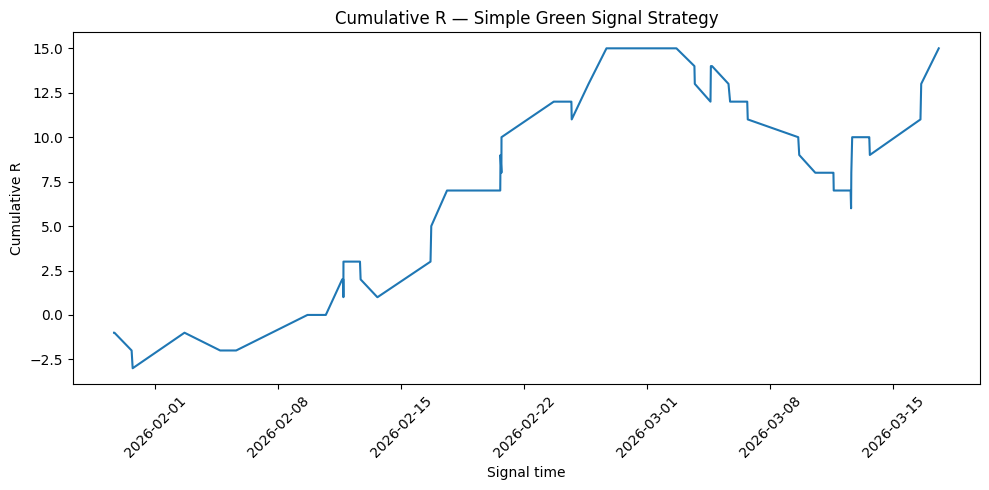

In [328]:
import matplotlib.pyplot as plt

if len(diagnostic_trade_log) > 0:
    plt.figure(figsize=(10, 5))
    plt.plot(diagnostic_trade_log["signal_time"], diagnostic_trade_log["cumulative_R"])
    plt.title("Cumulative R — Simple Green Signal Strategy")
    plt.xlabel("Signal time")
    plt.ylabel("Cumulative R")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Section 8 Notes

This commit adds diagnostics only.

No trading rules were changed.

The next strategy-improvement commit should be chosen based on these diagnostics.

Possible next filters:

- red-band shift strength filter
- time-of-day filter
- body-ratio filter
- extension-from-green tightening
- trend-death filter

# 9. Strategy Filter Comparison

This section compares strategy variants on the current dataset.

The aim is to test possible filters before hard-coding them.

Direction-only variants are intentionally excluded because the strategy should remain able to trade both long and short setups.

In [329]:
def signal_time_london_series(df: pd.DataFrame, config: dict) -> pd.Series:
    """
    Return signal timestamps converted to the configured session timezone.
    """
    return df["datetime"].apply(lambda ts: normalise_timestamp_to_session_time(ts, config))


def trade_directional_red_shift_label(df: pd.DataFrame) -> pd.Series:
    """
    For signal rows, return the red-shift label in the direction of the signal.
    """
    return np.where(
        df["simple_signal_side"] == "long",
        df["bullish_red_shift_label"],
        np.where(
            df["simple_signal_side"] == "short",
            df["bearish_red_shift_label"],
            "none",
        ),
    )


def trade_directional_red_shift_strength(df: pd.DataFrame) -> pd.Series:
    """
    For signal rows, return the red-shift strength in the direction of the signal.
    """
    return np.where(
        df["simple_signal_side"] == "long",
        df["bullish_red_shift_strength"],
        np.where(
            df["simple_signal_side"] == "short",
            df["bearish_red_shift_strength"],
            np.nan,
        ),
    )


def trade_directional_extension_from_green(df: pd.DataFrame) -> pd.Series:
    """
    For signal rows, return extension from green in the direction of the trade.
    """
    return np.where(
        df["simple_signal_side"] == "long",
        df["long_extension_from_green_points"],
        np.where(
            df["simple_signal_side"] == "short",
            df["short_extension_from_green_points"],
            np.nan,
        ),
    )

In [330]:
def run_filtered_strategy_variant(
    base_signal_df: pd.DataFrame,
    config: dict,
    variant_name: str,
    keep_mask: pd.Series,
) -> dict:
    """
    Apply a signal filter, rerun the simulator, and return a compact performance summary.

    Filtered-out signals are converted into NO_SIGNAL rows so the original DataFrame
    structure is preserved.
    """
    filtered_df = base_signal_df.copy()

    original_signal_count = int((filtered_df["simple_signal_name"] != "NO_SIGNAL").sum())

    keep_mask = keep_mask.reindex(filtered_df.index).fillna(False)

    remove_mask = (filtered_df["simple_signal_name"] != "NO_SIGNAL") & ~keep_mask

    filtered_df.loc[remove_mask, "simple_signal_name"] = "NO_SIGNAL"
    filtered_df.loc[remove_mask, "simple_signal_side"] = "none"

    kept_signal_count = int((filtered_df["simple_signal_name"] != "NO_SIGNAL").sum())

    trades, skipped = simulate_fixed_point_trades_with_daily_controls(
        filtered_df,
        config,
    )

    if trades.empty:
        return {
            "variant": variant_name,
            "original_signals": original_signal_count,
            "kept_signals": kept_signal_count,
            "filtered_out_signals": original_signal_count - kept_signal_count,
            "trades": 0,
            "TP": 0,
            "SL": 0,
            "BE": 0,
            "DATA_END": 0,
            "skipped_signals": len(skipped),
            "total_points": 0.0,
            "avg_points": np.nan,
            "total_R": 0.0,
            "avg_R": np.nan,
            "total_account_pct": 0.0,
            "win_rate_ex_BE": np.nan,
            "avg_bars_held": np.nan,
        }

    wins = int((trades["exit_reason"] == "TP").sum())
    losses = int((trades["exit_reason"] == "SL").sum())
    breakevens = int((trades["exit_reason"] == "BE").sum())
    data_end = int((trades["exit_reason"] == "DATA_END").sum())

    win_rate_ex_be = wins / max(1, wins + losses)

    return {
        "variant": variant_name,
        "original_signals": original_signal_count,
        "kept_signals": kept_signal_count,
        "filtered_out_signals": original_signal_count - kept_signal_count,
        "trades": len(trades),
        "TP": wins,
        "SL": losses,
        "BE": breakevens,
        "DATA_END": data_end,
        "skipped_signals": len(skipped),
        "total_points": trades["points_result"].sum(),
        "avg_points": trades["points_result"].mean(),
        "total_R": trades["R_result"].sum(),
        "avg_R": trades["R_result"].mean(),
        "total_account_pct": trades["account_pct_result"].sum(),
        "win_rate_ex_BE": win_rate_ex_be,
        "avg_bars_held": trades["bars_held"].mean(),
    }

In [331]:
def build_strategy_variant_masks(signal_df: pd.DataFrame, config: dict) -> dict[str, pd.Series]:
    """
    Build candidate strategy filters for comparison.

    Direction-only variants are intentionally excluded because the strategy
    should remain able to trade both long and short setups.
    """
    df = signal_df.copy()

    has_signal = df["simple_signal_name"] != "NO_SIGNAL"

    london_time = signal_time_london_series(df, config)
    london_hour = london_time.dt.hour

    directional_extension = pd.Series(
        trade_directional_extension_from_green(df),
        index=df.index,
    )

    directional_red_shift_label = pd.Series(
        trade_directional_red_shift_label(df),
        index=df.index,
    )

    directional_red_shift_strength = pd.Series(
        trade_directional_red_shift_strength(df),
        index=df.index,
    )

    masks = {
        "baseline": has_signal,

        # Time filters, both directions allowed
        "14_16_london_only": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
        ),
        "before_16_london": (
            has_signal
            & (london_hour < 16)
        ),
        "before_18_london": (
            has_signal
            & (london_hour < 18)
        ),
        "exclude_16_18_london": (
            has_signal
            & ~((london_hour >= 16) & (london_hour < 18))
        ),

        # Candle body filters, both directions allowed
        "body_ratio_ge_0_50": (
            has_signal
            & (df["body_ratio"] >= 0.50)
        ),
        "body_ratio_ge_0_75": (
            has_signal
            & (df["body_ratio"] >= 0.75)
        ),

        # Extension filters, both directions allowed
        "extension_le_4": (
            has_signal
            & (directional_extension <= 4.0)
        ),
        "extension_le_6": (
            has_signal
            & (directional_extension <= 6.0)
        ),
        "extension_2_to_4": (
            has_signal
            & (directional_extension >= 2.0)
            & (directional_extension <= 4.0)
        ),

        # Red-shift filters, both directions allowed
        "exclude_extreme_red_shift": (
            has_signal
            & ~directional_red_shift_label.isin(
                ["extreme", "abnormal_news_or_crash_regime"]
            )
        ),
        "exclude_strong_plus_red_shift": (
            has_signal
            & ~directional_red_shift_label.isin(
                ["strong", "very_strong", "extreme", "abnormal_news_or_crash_regime"]
            )
        ),
        "weak_red_shift_only": (
            has_signal
            & (directional_red_shift_label == "weak")
        ),
        "minimum_to_very_strong_red_shift": (
            has_signal
            & directional_red_shift_label.isin(
                ["minimum", "good", "strong", "very_strong"]
            )
        ),

        # Combined filters, both directions allowed
        "14_16_extension_le_4": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
            & (directional_extension <= 4.0)
        ),
        "14_16_extension_le_6": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
            & (directional_extension <= 6.0)
        ),
        "14_16_body_ge_0_50": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
            & (df["body_ratio"] >= 0.50)
        ),
        "14_16_body_ge_0_75": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
            & (df["body_ratio"] >= 0.75)
        ),
        "14_16_extension_le_4_body_ge_0_50": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
            & (directional_extension <= 4.0)
            & (df["body_ratio"] >= 0.50)
        ),
        "14_16_extension_le_6_body_ge_0_50": (
            has_signal
            & (london_hour >= 14)
            & (london_hour < 16)
            & (directional_extension <= 6.0)
            & (df["body_ratio"] >= 0.50)
        ),

        # General combined filters, both directions allowed
        "body_ge_0_50_extension_le_6": (
            has_signal
            & (df["body_ratio"] >= 0.50)
            & (directional_extension <= 6.0)
        ),
        "body_ge_0_50_extension_le_4": (
            has_signal
            & (df["body_ratio"] >= 0.50)
            & (directional_extension <= 4.0)
        ),
        "body_ge_0_75_extension_le_6": (
            has_signal
            & (df["body_ratio"] >= 0.75)
            & (directional_extension <= 6.0)
        ),
        "body_ge_0_75_extension_le_4": (
            has_signal
            & (df["body_ratio"] >= 0.75)
            & (directional_extension <= 4.0)
        ),
    }

    return masks

In [332]:
variant_masks = build_strategy_variant_masks(signals_df, AUTO_CONFIG)

variant_results = []

for variant_name, keep_mask in variant_masks.items():
    result = run_filtered_strategy_variant(
        base_signal_df=signals_df,
        config=AUTO_CONFIG,
        variant_name=variant_name,
        keep_mask=keep_mask,
    )
    variant_results.append(result)

variant_comparison = pd.DataFrame(variant_results)

variant_comparison = variant_comparison.sort_values(
    ["total_R", "avg_R"],
    ascending=False,
).reset_index(drop=True)

display(variant_comparison)

,variant,original_signals,kept_signals,filtered_out_signals,trades,TP,SL,BE,DATA_END,skipped_signals,total_points,avg_points,total_R,avg_R,total_account_pct,win_rate_ex_BE,avg_bars_held
0,weak_red_shift_only,113,71,42,42,15,12,15,0,0,522.0,12.428571,18.0,0.428571,18.0,0.555556,17.833333
1,exclude_extreme_red_shift,113,110,3,63,18,19,26,0,1,493.0,7.825397,17.0,0.269841,17.0,0.486486,15.396825
2,exclude_strong_plus_red_shift,113,94,19,53,16,16,21,0,1,464.0,8.754717,16.0,0.301887,16.0,0.500000,16.094340
3,body_ratio_ge_0_50,113,76,37,52,15,15,22,0,1,435.0,8.365385,15.0,0.288462,15.0,0.500000,15.519231
4,baseline,113,113,0,65,18,21,26,0,1,435.0,6.692308,15.0,0.230769,15.0,0.461538,15.000000
5,before_18_london,113,113,0,65,18,21,26,0,1,435.0,6.692308,15.0,0.230769,15.0,0.461538,15.000000
6,before_16_london,113,67,46,36,12,10,14,0,0,406.0,11.277778,14.0,0.388889,14.0,0.545455,21.472222
7,exclude_16_18_london,113,67,46,36,12,10,14,0,0,406.0,11.277778,14.0,0.388889,14.0,0.545455,21.472222
8,body_ge_0_50_extension_le_6,113,51,62,41,13,12,16,0,0,406.0,9.902439,14.0,0.341463,14.0,0.520000,15.512195
9,extension_le_6,113,80,33,52,16,18,18,0,0,406.0,7.807692,14.0,0.269231,14.0,0.470588,15.211538


In [333]:
MIN_TRADES_FOR_COMPARISON = 10

robust_variant_comparison = (
    variant_comparison[variant_comparison["trades"] >= MIN_TRADES_FOR_COMPARISON]
    .sort_values(["total_R", "avg_R"], ascending=False)
    .reset_index(drop=True)
)

display(robust_variant_comparison)

,variant,original_signals,kept_signals,filtered_out_signals,trades,TP,SL,BE,DATA_END,skipped_signals,total_points,avg_points,total_R,avg_R,total_account_pct,win_rate_ex_BE,avg_bars_held
0,weak_red_shift_only,113,71,42,42,15,12,15,0,0,522.0,12.428571,18.0,0.428571,18.0,0.555556,17.833333
1,exclude_extreme_red_shift,113,110,3,63,18,19,26,0,1,493.0,7.825397,17.0,0.269841,17.0,0.486486,15.396825
2,exclude_strong_plus_red_shift,113,94,19,53,16,16,21,0,1,464.0,8.754717,16.0,0.301887,16.0,0.500000,16.094340
3,body_ratio_ge_0_50,113,76,37,52,15,15,22,0,1,435.0,8.365385,15.0,0.288462,15.0,0.500000,15.519231
4,baseline,113,113,0,65,18,21,26,0,1,435.0,6.692308,15.0,0.230769,15.0,0.461538,15.000000
5,before_18_london,113,113,0,65,18,21,26,0,1,435.0,6.692308,15.0,0.230769,15.0,0.461538,15.000000
6,before_16_london,113,67,46,36,12,10,14,0,0,406.0,11.277778,14.0,0.388889,14.0,0.545455,21.472222
7,exclude_16_18_london,113,67,46,36,12,10,14,0,0,406.0,11.277778,14.0,0.388889,14.0,0.545455,21.472222
8,body_ge_0_50_extension_le_6,113,51,62,41,13,12,16,0,0,406.0,9.902439,14.0,0.341463,14.0,0.520000,15.512195
9,extension_le_6,113,80,33,52,16,18,18,0,0,406.0,7.807692,14.0,0.269231,14.0,0.470588,15.211538


In [334]:
baseline_row = variant_comparison[variant_comparison["variant"] == "baseline"].iloc[0]

variant_comparison_vs_baseline = variant_comparison.copy()

variant_comparison_vs_baseline["delta_total_R_vs_baseline"] = (
    variant_comparison_vs_baseline["total_R"] - baseline_row["total_R"]
)

variant_comparison_vs_baseline["delta_avg_R_vs_baseline"] = (
    variant_comparison_vs_baseline["avg_R"] - baseline_row["avg_R"]
)

variant_comparison_vs_baseline["delta_trades_vs_baseline"] = (
    variant_comparison_vs_baseline["trades"] - baseline_row["trades"]
)

display(
    variant_comparison_vs_baseline[
        [
            "variant",
            "kept_signals",
            "trades",
            "TP",
            "SL",
            "BE",
            "total_R",
            "avg_R",
            "win_rate_ex_BE",
            "total_points",
            "delta_total_R_vs_baseline",
            "delta_avg_R_vs_baseline",
            "delta_trades_vs_baseline",
        ]
    ].sort_values("delta_total_R_vs_baseline", ascending=False)
)

,variant,kept_signals,trades,TP,SL,BE,total_R,avg_R,win_rate_ex_BE,total_points,delta_total_R_vs_baseline,delta_avg_R_vs_baseline,delta_trades_vs_baseline
0,weak_red_shift_only,71,42,15,12,15,18.0,0.428571,0.555556,522.0,3.0,0.197802,-23
1,exclude_extreme_red_shift,110,63,18,19,26,17.0,0.269841,0.486486,493.0,2.0,0.039072,-2
2,exclude_strong_plus_red_shift,94,53,16,16,21,16.0,0.301887,0.500000,464.0,1.0,0.071118,-12
3,body_ratio_ge_0_50,76,52,15,15,22,15.0,0.288462,0.500000,435.0,0.0,0.057692,-13
4,baseline,113,65,18,21,26,15.0,0.230769,0.461538,435.0,0.0,0.000000,0
5,before_18_london,113,65,18,21,26,15.0,0.230769,0.461538,435.0,0.0,0.000000,0
6,before_16_london,67,36,12,10,14,14.0,0.388889,0.545455,406.0,-1.0,0.158120,-29
7,exclude_16_18_london,67,36,12,10,14,14.0,0.388889,0.545455,406.0,-1.0,0.158120,-29
8,body_ge_0_50_extension_le_6,51,41,13,12,16,14.0,0.341463,0.520000,406.0,-1.0,0.110694,-24
9,extension_le_6,80,52,16,18,18,14.0,0.269231,0.470588,406.0,-1.0,0.038462,-13


In [335]:
top_avg_R_variants = (
    variant_comparison[variant_comparison["trades"] >= MIN_TRADES_FOR_COMPARISON]
    .sort_values("avg_R", ascending=False)
    .reset_index(drop=True)
)

display(
    top_avg_R_variants[
        [
            "variant",
            "kept_signals",
            "trades",
            "TP",
            "SL",
            "BE",
            "total_R",
            "avg_R",
            "win_rate_ex_BE",
            "total_account_pct",
        ]
    ]
)

,variant,kept_signals,trades,TP,SL,BE,total_R,avg_R,win_rate_ex_BE,total_account_pct
0,body_ge_0_75_extension_le_4,12,12,5,2,5,8.0,0.666667,0.714286,8.0
1,body_ge_0_75_extension_le_6,20,19,8,5,6,11.0,0.578947,0.615385,11.0
2,14_16_body_ge_0_75,16,15,6,5,4,7.0,0.466667,0.545455,7.0
3,body_ratio_ge_0_75,29,25,9,7,9,11.0,0.440000,0.562500,11.0
4,weak_red_shift_only,71,42,15,12,15,18.0,0.428571,0.555556,18.0
5,exclude_16_18_london,67,36,12,10,14,14.0,0.388889,0.545455,14.0
6,before_16_london,67,36,12,10,14,14.0,0.388889,0.545455,14.0
7,14_16_body_ge_0_50,41,29,10,9,10,11.0,0.379310,0.526316,11.0
8,14_16_extension_le_6_body_ge_0_50,30,23,8,8,7,8.0,0.347826,0.500000,8.0
9,body_ge_0_50_extension_le_6,51,41,13,12,16,14.0,0.341463,0.520000,14.0


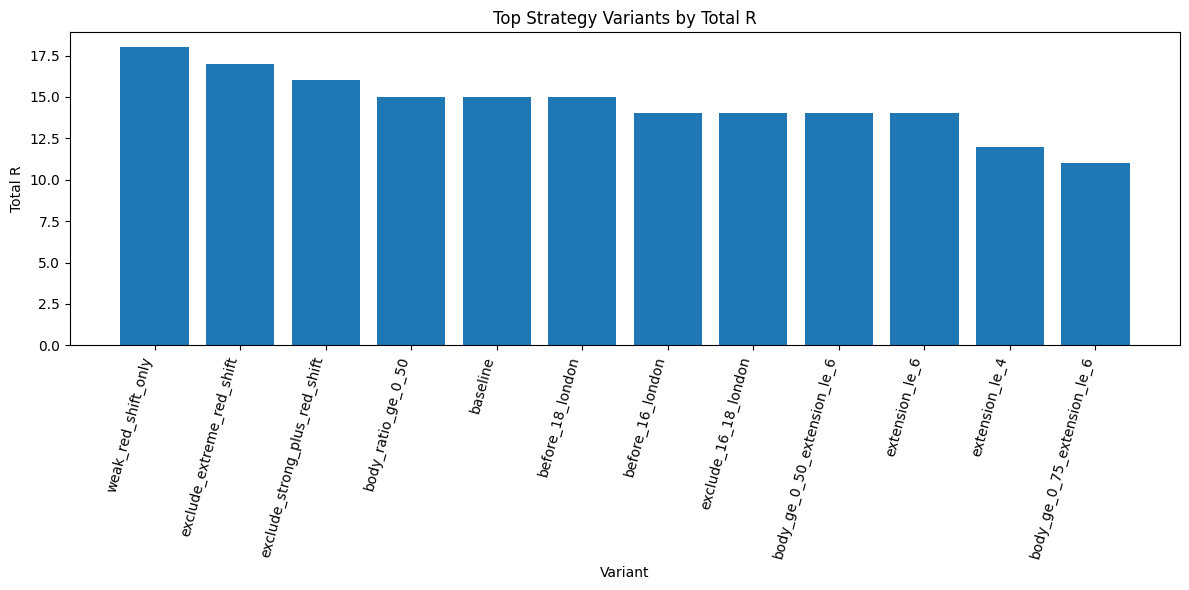

In [336]:
import matplotlib.pyplot as plt

plot_df = robust_variant_comparison.head(12).copy()

if len(plot_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.bar(plot_df["variant"], plot_df["total_R"])
    plt.title("Top Strategy Variants by Total R")
    plt.xlabel("Variant")
    plt.ylabel("Total R")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

## Section 9 Notes

This commit compares strategy variants without permanently changing the base strategy.

No trading rules were changed.

Direction-only variants are intentionally excluded because the strategy should remain able to trade both long and short setups.

The next commit should only hard-code a filter if the comparison table shows a clear improvement with a reasonable number of trades.

Possible next commits:

- add time-window filter
- add extension-from-green filter
- add body-ratio filter
- add combined quality filter
- keep baseline unchanged and test on the 1-year file
- add a parameter experiment grid for SL / TP / breakeven testing

# 10. Multi-Dataset Strategy Comparison

This section reruns the same strategy variants across multiple datasets.

Current datasets:

- 30-day Nasdaq M1 sample
- 1-year Nasdaq M1 sample

The purpose is to avoid overfitting one short dataset before selecting a Base V1.

In [337]:
MULTI_DATASET_FILES = [
    "US100_cash_M1_NY_session_30d.csv",
    "US100_cash_M1_NY_session_1y.csv",
]

MULTI_DATASET_FILES

['US100_cash_M1_NY_session_30d.csv', 'US100_cash_M1_NY_session_1y.csv']

In [338]:
def find_data_file_by_name(file_name: str) -> Path | None:
    """
    Find a data file by name inside the project.
    """
    candidate_files = list_candidate_data_files()

    matching_files = [
        file for file in candidate_files
        if file.name == file_name
    ]

    if not matching_files:
        return None

    return matching_files[0]


def load_raw_data_file(file_path: Path) -> pd.DataFrame:
    """
    Load CSV or Parquet raw market data.
    """
    if file_path.suffix.lower() == ".csv":
        return pd.read_csv(file_path)

    if file_path.suffix.lower() == ".parquet":
        return pd.read_parquet(file_path)

    raise ValueError(f"Unsupported file type: {file_path.suffix}")

In [339]:
def build_signals_from_dataset(file_name: str, config: dict, engine_config: dict) -> tuple[pd.DataFrame, dict]:
    """
    Run the full research pipeline for one dataset.

    Returns
    -------
    signals_df:
        DataFrame with simple green reclaim / rejection signals.
    metadata:
        Basic dataset metadata.
    """
    file_path = find_data_file_by_name(file_name)

    if file_path is None:
        raise FileNotFoundError(f"Could not find dataset: {file_name}")

    raw_df = load_raw_data_file(file_path)
    raw_ohlc = prepare_raw_ohlc_dataframe(raw_df)

    engine_output = build_existing_engine_output(raw_ohlc, engine_config)
    automation_ready = prepare_automation_dataframe(engine_output)
    features = add_automation_features(automation_ready, config)
    signals = add_simple_green_signals(features, config)

    signal_count = int((signals["simple_signal_name"] != "NO_SIGNAL").sum())

    metadata = {
        "dataset": file_name,
        "file_path": str(file_path.relative_to(PROJECT_ROOT)),
        "raw_rows": len(raw_df),
        "prepared_rows": len(raw_ohlc),
        "engine_rows": len(engine_output),
        "signal_rows": signal_count,
        "start_time": signals["datetime"].min(),
        "end_time": signals["datetime"].max(),
    }

    return signals, metadata

In [340]:
def run_variant_comparison_for_dataset(
    file_name: str,
    config: dict,
    engine_config: dict,
) -> tuple[pd.DataFrame, dict]:
    """
    Build signals for one dataset and run all strategy variants.
    """
    dataset_signals_df, metadata = build_signals_from_dataset(
        file_name=file_name,
        config=config,
        engine_config=engine_config,
    )

    variant_masks = build_strategy_variant_masks(dataset_signals_df, config)

    variant_results = []

    for variant_name, keep_mask in variant_masks.items():
        result = run_filtered_strategy_variant(
            base_signal_df=dataset_signals_df,
            config=config,
            variant_name=variant_name,
            keep_mask=keep_mask,
        )

        result["dataset"] = file_name
        result["dataset_rows"] = metadata["engine_rows"]
        result["dataset_signals"] = metadata["signal_rows"]
        result["dataset_start_time"] = metadata["start_time"]
        result["dataset_end_time"] = metadata["end_time"]

        variant_results.append(result)

    comparison = pd.DataFrame(variant_results)

    comparison["R_per_trade"] = np.where(
        comparison["trades"] > 0,
        comparison["total_R"] / comparison["trades"],
        np.nan,
    )

    comparison["R_per_100_trades"] = comparison["R_per_trade"] * 100

    comparison = comparison.sort_values(
        ["total_R", "avg_R"],
        ascending=False,
    ).reset_index(drop=True)

    return comparison, metadata

In [341]:
multi_dataset_results = []
multi_dataset_metadata = []

for file_name in MULTI_DATASET_FILES:
    print(f"Running dataset: {file_name}")

    try:
        dataset_comparison, dataset_metadata = run_variant_comparison_for_dataset(
            file_name=file_name,
            config=AUTO_CONFIG,
            engine_config=CONFIG,
        )

        multi_dataset_results.append(dataset_comparison)
        multi_dataset_metadata.append(dataset_metadata)

        print(
            f"Done: {file_name} | "
            f"rows={dataset_metadata['engine_rows']:,} | "
            f"signals={dataset_metadata['signal_rows']:,}"
        )

    except FileNotFoundError as exc:
        print(exc)

multi_dataset_metadata_df = pd.DataFrame(multi_dataset_metadata)

display(multi_dataset_metadata_df)

Running dataset: US100_cash_M1_NY_session_30d.csv
All required automation columns are present.
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 37.132500
   Min sigma  : 14.478627
   Max sigma  : 145.465266
   Floor used : 14.478627
All required automation columns are present.
Done: US100_cash_M1_NY_session_30d.csv | rows=6,728 | signals=113
Running dataset: US100_cash_M1_NY_session_1y.csv
All required automation columns are present.
✅ VWAP computed — resets per session: True
✅ Sigma computed (ewma)
   Mean sigma : 20.872847
   Min sigma  : 6.269622
   Max sigma  : 332.844379
   Floor used : 6.269622
All required automation columns are present.
Done: US100_cash_M1_NY_session_1y.csv | rows=51,666 | signals=854


,dataset,file_path,raw_rows,prepared_rows,engine_rows,signal_rows,start_time,end_time
0,US100_cash_M1_NY_session_30d.csv,data\historical\US100_cash_M1_NY_session_30d.csv,6728,6728,6728,113,2026-01-29 15:22:00+00:00,2026-03-17 16:29:00+00:00
1,US100_cash_M1_NY_session_1y.csv,data\historical\US100_cash_M1_NY_session_1y.csv,51666,51666,51666,854,2025-05-16 13:10:00+00:00,2026-05-15 16:29:00+00:00


In [342]:
multi_dataset_variant_results = pd.concat(
    multi_dataset_results,
    ignore_index=True,
) if multi_dataset_results else pd.DataFrame()

display(
    multi_dataset_variant_results[
        [
            "dataset",
            "variant",
            "kept_signals",
            "trades",
            "TP",
            "SL",
            "BE",
            "total_R",
            "avg_R",
            "R_per_100_trades",
            "win_rate_ex_BE",
            "total_account_pct",
        ]
    ].sort_values(["dataset", "total_R"], ascending=[True, False])
)

,dataset,variant,kept_signals,trades,TP,SL,BE,total_R,avg_R,R_per_100_trades,win_rate_ex_BE,total_account_pct
24,US100_cash_M1_NY_session_1y.csv,weak_red_shift_only,609,270,87,118,65,56.0,0.207407,20.740741,0.424390,56.0
25,US100_cash_M1_NY_session_1y.csv,exclude_extreme_red_shift,847,361,104,161,96,47.0,0.130194,13.019391,0.392453,47.0
26,US100_cash_M1_NY_session_1y.csv,baseline,854,365,104,164,97,44.0,0.120548,12.054795,0.388060,44.0
27,US100_cash_M1_NY_session_1y.csv,before_18_london,854,365,104,164,97,44.0,0.120548,12.054795,0.388060,44.0
28,US100_cash_M1_NY_session_1y.csv,exclude_strong_plus_red_shift,762,322,94,145,83,43.0,0.133540,13.354037,0.393305,43.0
29,US100_cash_M1_NY_session_1y.csv,body_ratio_ge_0_50,578,283,82,123,78,41.0,0.144876,14.487633,0.400000,41.0
30,US100_cash_M1_NY_session_1y.csv,extension_le_6,744,318,92,144,82,40.0,0.125786,12.578616,0.389831,40.0
31,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_6,493,239,70,102,67,38.0,0.158996,15.899582,0.406977,38.0
32,US100_cash_M1_NY_session_1y.csv,extension_le_4,573,267,78,121,68,35.0,0.131086,13.108614,0.391960,35.0
33,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_4,375,191,58,83,50,33.0,0.172775,17.277487,0.411348,33.0


In [343]:
MIN_TRADES_MULTI_DATASET = 30

robust_multi_dataset_results = (
    multi_dataset_variant_results[
        multi_dataset_variant_results["trades"] >= MIN_TRADES_MULTI_DATASET
    ]
    .copy()
    .sort_values(["dataset", "total_R"], ascending=[True, False])
    .reset_index(drop=True)
)

display(
    robust_multi_dataset_results[
        [
            "dataset",
            "variant",
            "kept_signals",
            "trades",
            "TP",
            "SL",
            "BE",
            "total_R",
            "avg_R",
            "R_per_100_trades",
            "win_rate_ex_BE",
            "total_account_pct",
        ]
    ]
)

,dataset,variant,kept_signals,trades,TP,SL,BE,total_R,avg_R,R_per_100_trades,win_rate_ex_BE,total_account_pct
0,US100_cash_M1_NY_session_1y.csv,weak_red_shift_only,609,270,87,118,65,56.0,0.207407,20.740741,0.424390,56.0
1,US100_cash_M1_NY_session_1y.csv,exclude_extreme_red_shift,847,361,104,161,96,47.0,0.130194,13.019391,0.392453,47.0
2,US100_cash_M1_NY_session_1y.csv,baseline,854,365,104,164,97,44.0,0.120548,12.054795,0.388060,44.0
3,US100_cash_M1_NY_session_1y.csv,before_18_london,854,365,104,164,97,44.0,0.120548,12.054795,0.388060,44.0
4,US100_cash_M1_NY_session_1y.csv,exclude_strong_plus_red_shift,762,322,94,145,83,43.0,0.133540,13.354037,0.393305,43.0
5,US100_cash_M1_NY_session_1y.csv,body_ratio_ge_0_50,578,283,82,123,78,41.0,0.144876,14.487633,0.400000,41.0
6,US100_cash_M1_NY_session_1y.csv,extension_le_6,744,318,92,144,82,40.0,0.125786,12.578616,0.389831,40.0
7,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_6,493,239,70,102,67,38.0,0.158996,15.899582,0.406977,38.0
8,US100_cash_M1_NY_session_1y.csv,extension_le_4,573,267,78,121,68,35.0,0.131086,13.108614,0.391960,35.0
9,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_4,375,191,58,83,50,33.0,0.172775,17.277487,0.411348,33.0


In [344]:
# Compare all variants against the baseline inside each dataset.

baseline_by_dataset = (
    multi_dataset_variant_results[
        multi_dataset_variant_results["variant"] == "baseline"
    ][
        [
            "dataset",
            "trades",
            "total_R",
            "avg_R",
            "win_rate_ex_BE",
            "total_account_pct",
        ]
    ]
    .rename(
        columns={
            "trades": "baseline_trades",
            "total_R": "baseline_total_R",
            "avg_R": "baseline_avg_R",
            "win_rate_ex_BE": "baseline_win_rate_ex_BE",
            "total_account_pct": "baseline_account_pct",
        }
    )
)

multi_vs_baseline = multi_dataset_variant_results.merge(
    baseline_by_dataset,
    on="dataset",
    how="left",
)

multi_vs_baseline["delta_total_R_vs_baseline"] = (
    multi_vs_baseline["total_R"] - multi_vs_baseline["baseline_total_R"]
)

multi_vs_baseline["delta_avg_R_vs_baseline"] = (
    multi_vs_baseline["avg_R"] - multi_vs_baseline["baseline_avg_R"]
)

multi_vs_baseline["delta_trades_vs_baseline"] = (
    multi_vs_baseline["trades"] - multi_vs_baseline["baseline_trades"]
)

display(
    multi_vs_baseline[
        [
            "dataset",
            "variant",
            "kept_signals",
            "trades",
            "TP",
            "SL",
            "BE",
            "total_R",
            "avg_R",
            "win_rate_ex_BE",
            "delta_total_R_vs_baseline",
            "delta_avg_R_vs_baseline",
            "delta_trades_vs_baseline",
        ]
    ].sort_values(["dataset", "delta_total_R_vs_baseline"], ascending=[True, False])
)

,dataset,variant,kept_signals,trades,TP,SL,BE,total_R,avg_R,win_rate_ex_BE,delta_total_R_vs_baseline,delta_avg_R_vs_baseline,delta_trades_vs_baseline
24,US100_cash_M1_NY_session_1y.csv,weak_red_shift_only,609,270,87,118,65,56.0,0.207407,0.424390,12.0,0.086859,-95
25,US100_cash_M1_NY_session_1y.csv,exclude_extreme_red_shift,847,361,104,161,96,47.0,0.130194,0.392453,3.0,0.009646,-4
26,US100_cash_M1_NY_session_1y.csv,baseline,854,365,104,164,97,44.0,0.120548,0.388060,0.0,0.000000,0
27,US100_cash_M1_NY_session_1y.csv,before_18_london,854,365,104,164,97,44.0,0.120548,0.388060,0.0,0.000000,0
28,US100_cash_M1_NY_session_1y.csv,exclude_strong_plus_red_shift,762,322,94,145,83,43.0,0.133540,0.393305,-1.0,0.012992,-43
29,US100_cash_M1_NY_session_1y.csv,body_ratio_ge_0_50,578,283,82,123,78,41.0,0.144876,0.400000,-3.0,0.024328,-82
30,US100_cash_M1_NY_session_1y.csv,extension_le_6,744,318,92,144,82,40.0,0.125786,0.389831,-4.0,0.005238,-47
31,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_6,493,239,70,102,67,38.0,0.158996,0.406977,-6.0,0.038448,-126
32,US100_cash_M1_NY_session_1y.csv,extension_le_4,573,267,78,121,68,35.0,0.131086,0.391960,-9.0,0.010538,-98
33,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_4,375,191,58,83,50,33.0,0.172775,0.411348,-11.0,0.052227,-174


In [345]:
# Stability table: summarise each variant across all available datasets.

variant_stability = (
    multi_dataset_variant_results
    .groupby("variant")
    .agg(
        datasets_tested=("dataset", "nunique"),
        total_trades_all=("trades", "sum"),
        total_R_all=("total_R", "sum"),
        avg_R_mean=("avg_R", "mean"),
        avg_R_min=("avg_R", "min"),
        avg_R_max=("avg_R", "max"),
        R_per_100_trades_mean=("R_per_100_trades", "mean"),
        win_rate_ex_BE_mean=("win_rate_ex_BE", "mean"),
        total_account_pct_all=("total_account_pct", "sum"),
    )
    .reset_index()
)

variant_stability["stable_positive_avg_R"] = variant_stability["avg_R_min"] > 0

variant_stability = variant_stability.sort_values(
    ["stable_positive_avg_R", "total_R_all", "avg_R_mean"],
    ascending=False,
).reset_index(drop=True)

display(variant_stability)

,variant,datasets_tested,total_trades_all,total_R_all,avg_R_mean,avg_R_min,avg_R_max,R_per_100_trades_mean,win_rate_ex_BE_mean,total_account_pct_all,stable_positive_avg_R
0,weak_red_shift_only,2,312,74.0,0.317989,0.207407,0.428571,31.798942,0.489973,74.0,True
1,exclude_extreme_red_shift,2,424,64.0,0.200018,0.130194,0.269841,20.001759,0.439470,64.0,True
2,exclude_strong_plus_red_shift,2,375,59.0,0.217714,0.133540,0.301887,21.771358,0.446653,59.0,True
3,baseline,2,430,59.0,0.175659,0.120548,0.230769,17.565859,0.424799,59.0,True
4,before_18_london,2,430,59.0,0.175659,0.120548,0.230769,17.565859,0.424799,59.0,True
5,body_ratio_ge_0_50,2,335,56.0,0.216669,0.144876,0.288462,21.666893,0.450000,56.0,True
6,extension_le_6,2,370,54.0,0.197508,0.125786,0.269231,19.750847,0.430209,54.0,True
7,body_ge_0_50_extension_le_6,2,280,52.0,0.250230,0.158996,0.341463,25.022962,0.463488,52.0,True
8,extension_le_4,2,303,47.0,0.232210,0.131086,0.333333,23.220974,0.457885,47.0,True
9,body_ge_0_50_extension_le_4,2,219,41.0,0.229245,0.172775,0.285714,22.924458,0.455674,41.0,True


In [346]:
# Focus table for likely V1 candidates.

candidate_variants = [
    "baseline",
    "body_ratio_ge_0_50",
    "extension_le_6",
    "extension_le_4",
    "exclude_extreme_red_shift",
    "exclude_strong_plus_red_shift",
    "weak_red_shift_only",
    "body_ge_0_50_extension_le_6",
    "body_ge_0_50_extension_le_4",
    "14_16_london_only",
    "before_16_london",
]

candidate_multi_results = multi_vs_baseline[
    multi_vs_baseline["variant"].isin(candidate_variants)
].copy()

display(
    candidate_multi_results[
        [
            "dataset",
            "variant",
            "kept_signals",
            "trades",
            "TP",
            "SL",
            "BE",
            "total_R",
            "avg_R",
            "win_rate_ex_BE",
            "delta_total_R_vs_baseline",
            "delta_avg_R_vs_baseline",
            "delta_trades_vs_baseline",
        ]
    ].sort_values(["variant", "dataset"])
)

,dataset,variant,kept_signals,trades,TP,SL,BE,total_R,avg_R,win_rate_ex_BE,delta_total_R_vs_baseline,delta_avg_R_vs_baseline,delta_trades_vs_baseline
43,US100_cash_M1_NY_session_1y.csv,14_16_london_only,471,203,56,90,57,22.0,0.108374,0.383562,-22.0,-0.012174,-162
14,US100_cash_M1_NY_session_30d.csv,14_16_london_only,57,32,10,11,11,9.0,0.281250,0.476190,-6.0,0.050481,-33
26,US100_cash_M1_NY_session_1y.csv,baseline,854,365,104,164,97,44.0,0.120548,0.388060,0.0,0.000000,0
4,US100_cash_M1_NY_session_30d.csv,baseline,113,65,18,21,26,15.0,0.230769,0.461538,0.0,0.000000,0
41,US100_cash_M1_NY_session_1y.csv,before_16_london,489,210,58,92,60,24.0,0.114286,0.386667,-20.0,-0.006262,-155
6,US100_cash_M1_NY_session_30d.csv,before_16_london,67,36,12,10,14,14.0,0.388889,0.545455,-1.0,0.158120,-29
33,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_4,375,191,58,83,50,33.0,0.172775,0.411348,-11.0,0.052227,-174
18,US100_cash_M1_NY_session_30d.csv,body_ge_0_50_extension_le_4,29,28,8,8,12,8.0,0.285714,0.500000,-7.0,0.054945,-37
31,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_6,493,239,70,102,67,38.0,0.158996,0.406977,-6.0,0.038448,-126
8,US100_cash_M1_NY_session_30d.csv,body_ge_0_50_extension_le_6,51,41,13,12,16,14.0,0.341463,0.520000,-1.0,0.110694,-24


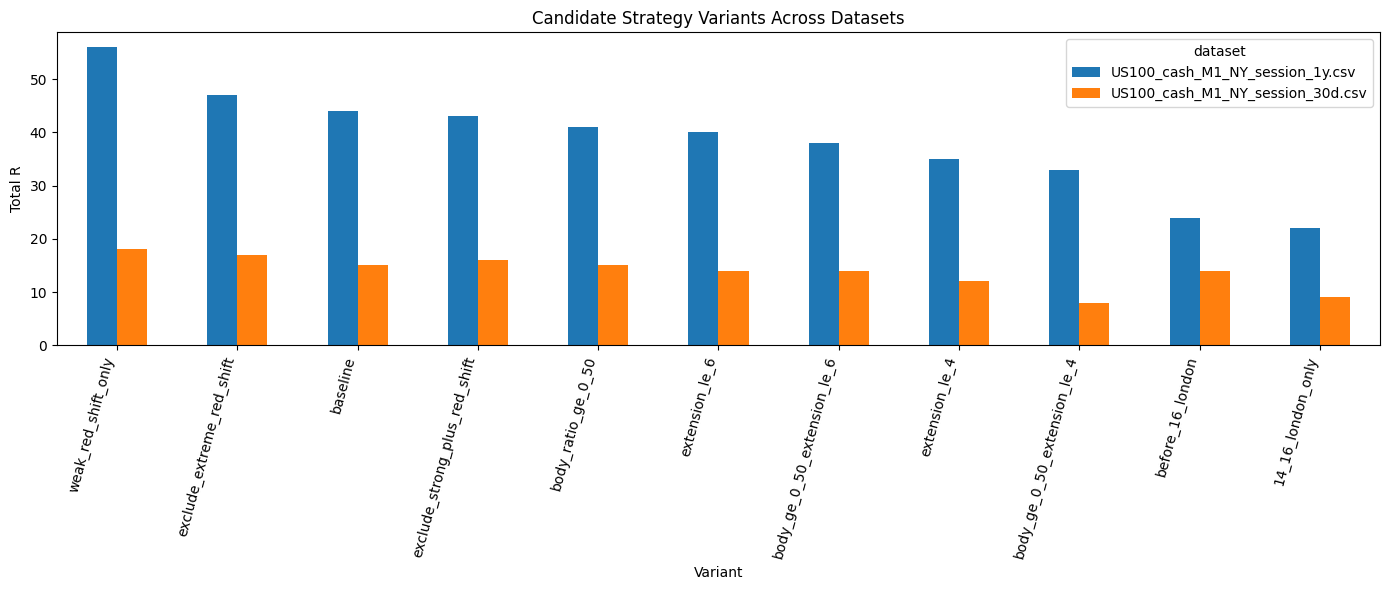

In [347]:
import matplotlib.pyplot as plt

if len(candidate_multi_results) > 0:
    plot_df = candidate_multi_results.copy()

    pivot_plot = plot_df.pivot_table(
        index="variant",
        columns="dataset",
        values="total_R",
        aggfunc="first",
    )

    pivot_plot = pivot_plot.loc[
        pivot_plot.sum(axis=1).sort_values(ascending=False).index
    ]

    ax = pivot_plot.plot(kind="bar", figsize=(14, 6))
    ax.set_title("Candidate Strategy Variants Across Datasets")
    ax.set_xlabel("Variant")
    ax.set_ylabel("Total R")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.show()

# Compact Performance Summary Tables

This section creates cleaner summary tables for reading the research results quickly.

It does not change any strategy rules.

The aim is to show the main performance numbers clearly:

- trades
- TP count
- SL count
- BE count
- win rate excluding breakevens
- total R
- average R
- total points
- account % result

In [348]:
def add_compact_performance_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add clean percentage/rate columns to strategy result tables.

    This is presentation-only.
    It does not change strategy logic.
    """
    out = df.copy()

    if "trades" in out.columns:
        trades = out["trades"].replace(0, np.nan)

        if "TP" in out.columns:
            out["TP_rate_all"] = out["TP"] / trades

        if "SL" in out.columns:
            out["SL_rate_all"] = out["SL"] / trades

        if "BE" in out.columns:
            out["BE_rate_all"] = out["BE"] / trades

    if {"TP", "SL"}.issubset(out.columns):
        decisive_trades = (out["TP"] + out["SL"]).replace(0, np.nan)
        out["WR_ex_BE"] = out["TP"] / decisive_trades

    # Cleaner rounded display columns
    for col in [
        "TP_rate_all",
        "SL_rate_all",
        "BE_rate_all",
        "WR_ex_BE",
        "win_rate_ex_BE",
        "avg_R",
        "total_R",
        "total_points",
        "total_account_pct",
        "R_per_100_trades",
    ]:
        if col in out.columns:
            out[col] = out[col].round(4)

    return out

In [349]:
def show_compact_results(
    df: pd.DataFrame,
    title: str,
    sort_cols: list[str] | None = None,
    ascending: bool | list[bool] = False,
    max_rows: int | None = None,
) -> pd.DataFrame:
    """
    Display a compact strategy-performance table.
    """
    compact = add_compact_performance_columns(df)

    preferred_cols = [
        "dataset",
        "variant",
        "kept_signals",
        "trades",
        "TP",
        "SL",
        "BE",
        "TP_rate_all",
        "SL_rate_all",
        "BE_rate_all",
        "WR_ex_BE",
        "win_rate_ex_BE",
        "total_R",
        "avg_R",
        "R_per_100_trades",
        "total_points",
        "total_account_pct",
        "delta_total_R_vs_baseline",
        "delta_avg_R_vs_baseline",
        "delta_trades_vs_baseline",
    ]

    display_cols = [col for col in preferred_cols if col in compact.columns]

    if sort_cols is not None:
        compact = compact.sort_values(sort_cols, ascending=ascending)

    if max_rows is not None:
        compact = compact.head(max_rows)

    print(title)
    display(compact[display_cols])

    return compact

In [350]:
# Compact current-dataset variant summary

if "variant_comparison" in globals() and isinstance(variant_comparison, pd.DataFrame):
    compact_variant_comparison = show_compact_results(
        variant_comparison,
        title="Compact Summary — Current Dataset Strategy Variants",
        sort_cols=["total_R", "avg_R"],
        ascending=[False, False],
    )

Compact Summary — Current Dataset Strategy Variants


,variant,kept_signals,trades,TP,SL,BE,TP_rate_all,SL_rate_all,BE_rate_all,WR_ex_BE,win_rate_ex_BE,total_R,avg_R,total_points,total_account_pct
0,weak_red_shift_only,71,42,15,12,15,0.3571,0.2857,0.3571,0.5556,0.5556,18.0,0.4286,522.0,18.0
1,exclude_extreme_red_shift,110,63,18,19,26,0.2857,0.3016,0.4127,0.4865,0.4865,17.0,0.2698,493.0,17.0
2,exclude_strong_plus_red_shift,94,53,16,16,21,0.3019,0.3019,0.3962,0.5000,0.5000,16.0,0.3019,464.0,16.0
3,body_ratio_ge_0_50,76,52,15,15,22,0.2885,0.2885,0.4231,0.5000,0.5000,15.0,0.2885,435.0,15.0
4,baseline,113,65,18,21,26,0.2769,0.3231,0.4000,0.4615,0.4615,15.0,0.2308,435.0,15.0
5,before_18_london,113,65,18,21,26,0.2769,0.3231,0.4000,0.4615,0.4615,15.0,0.2308,435.0,15.0
6,before_16_london,67,36,12,10,14,0.3333,0.2778,0.3889,0.5455,0.5455,14.0,0.3889,406.0,14.0
7,exclude_16_18_london,67,36,12,10,14,0.3333,0.2778,0.3889,0.5455,0.5455,14.0,0.3889,406.0,14.0
8,body_ge_0_50_extension_le_6,51,41,13,12,16,0.3171,0.2927,0.3902,0.5200,0.5200,14.0,0.3415,406.0,14.0
9,extension_le_6,80,52,16,18,18,0.3077,0.3462,0.3462,0.4706,0.4706,14.0,0.2692,406.0,14.0


In [351]:
# Compact multi-dataset summary

if "multi_dataset_variant_results" in globals() and isinstance(multi_dataset_variant_results, pd.DataFrame):
    compact_multi_dataset_results = show_compact_results(
        multi_dataset_variant_results,
        title="Compact Summary — Multi-Dataset Strategy Variants",
        sort_cols=["dataset", "total_R", "avg_R"],
        ascending=[True, False, False],
    )

Compact Summary — Multi-Dataset Strategy Variants


,dataset,variant,kept_signals,trades,TP,SL,BE,TP_rate_all,SL_rate_all,BE_rate_all,WR_ex_BE,win_rate_ex_BE,total_R,avg_R,R_per_100_trades,total_points,total_account_pct
24,US100_cash_M1_NY_session_1y.csv,weak_red_shift_only,609,270,87,118,65,0.3222,0.4370,0.2407,0.4244,0.4244,56.0,0.2074,20.7407,1624.0,56.0
25,US100_cash_M1_NY_session_1y.csv,exclude_extreme_red_shift,847,361,104,161,96,0.2881,0.4460,0.2659,0.3925,0.3925,47.0,0.1302,13.0194,1363.0,47.0
26,US100_cash_M1_NY_session_1y.csv,baseline,854,365,104,164,97,0.2849,0.4493,0.2658,0.3881,0.3881,44.0,0.1205,12.0548,1276.0,44.0
27,US100_cash_M1_NY_session_1y.csv,before_18_london,854,365,104,164,97,0.2849,0.4493,0.2658,0.3881,0.3881,44.0,0.1205,12.0548,1276.0,44.0
28,US100_cash_M1_NY_session_1y.csv,exclude_strong_plus_red_shift,762,322,94,145,83,0.2919,0.4503,0.2578,0.3933,0.3933,43.0,0.1335,13.3540,1247.0,43.0
29,US100_cash_M1_NY_session_1y.csv,body_ratio_ge_0_50,578,283,82,123,78,0.2898,0.4346,0.2756,0.4000,0.4000,41.0,0.1449,14.4876,1189.0,41.0
30,US100_cash_M1_NY_session_1y.csv,extension_le_6,744,318,92,144,82,0.2893,0.4528,0.2579,0.3898,0.3898,40.0,0.1258,12.5786,1160.0,40.0
31,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_6,493,239,70,102,67,0.2929,0.4268,0.2803,0.4070,0.4070,38.0,0.1590,15.8996,1102.0,38.0
32,US100_cash_M1_NY_session_1y.csv,extension_le_4,573,267,78,121,68,0.2921,0.4532,0.2547,0.3920,0.3920,35.0,0.1311,13.1086,1015.0,35.0
33,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_4,375,191,58,83,50,0.3037,0.4346,0.2618,0.4113,0.4113,33.0,0.1728,17.2775,957.0,33.0


In [352]:
# Compact candidate V1 summary

candidate_variants_for_summary = [
    "baseline",
    "weak_red_shift_only",
    "exclude_extreme_red_shift",
    "exclude_strong_plus_red_shift",
    "body_ratio_ge_0_50",
    "extension_le_6",
    "body_ge_0_50_extension_le_6",
]

if "multi_vs_baseline" in globals() and isinstance(multi_vs_baseline, pd.DataFrame):
    compact_candidate_summary = multi_vs_baseline[
        multi_vs_baseline["variant"].isin(candidate_variants_for_summary)
    ].copy()

    compact_candidate_summary = show_compact_results(
        compact_candidate_summary,
        title="Compact Summary — Candidate V1 Variants",
        sort_cols=["variant", "dataset"],
        ascending=[True, True],
    )

Compact Summary — Candidate V1 Variants


,dataset,variant,kept_signals,trades,TP,SL,BE,TP_rate_all,SL_rate_all,BE_rate_all,WR_ex_BE,win_rate_ex_BE,total_R,avg_R,R_per_100_trades,total_points,total_account_pct,delta_total_R_vs_baseline,delta_avg_R_vs_baseline,delta_trades_vs_baseline
26,US100_cash_M1_NY_session_1y.csv,baseline,854,365,104,164,97,0.2849,0.4493,0.2658,0.3881,0.3881,44.0,0.1205,12.0548,1276.0,44.0,0.0,0.000000,0
4,US100_cash_M1_NY_session_30d.csv,baseline,113,65,18,21,26,0.2769,0.3231,0.4000,0.4615,0.4615,15.0,0.2308,23.0769,435.0,15.0,0.0,0.000000,0
31,US100_cash_M1_NY_session_1y.csv,body_ge_0_50_extension_le_6,493,239,70,102,67,0.2929,0.4268,0.2803,0.4070,0.4070,38.0,0.1590,15.8996,1102.0,38.0,-6.0,0.038448,-126
8,US100_cash_M1_NY_session_30d.csv,body_ge_0_50_extension_le_6,51,41,13,12,16,0.3171,0.2927,0.3902,0.5200,0.5200,14.0,0.3415,34.1463,406.0,14.0,-1.0,0.110694,-24
29,US100_cash_M1_NY_session_1y.csv,body_ratio_ge_0_50,578,283,82,123,78,0.2898,0.4346,0.2756,0.4000,0.4000,41.0,0.1449,14.4876,1189.0,41.0,-3.0,0.024328,-82
3,US100_cash_M1_NY_session_30d.csv,body_ratio_ge_0_50,76,52,15,15,22,0.2885,0.2885,0.4231,0.5000,0.5000,15.0,0.2885,28.8462,435.0,15.0,0.0,0.057692,-13
25,US100_cash_M1_NY_session_1y.csv,exclude_extreme_red_shift,847,361,104,161,96,0.2881,0.4460,0.2659,0.3925,0.3925,47.0,0.1302,13.0194,1363.0,47.0,3.0,0.009646,-4
1,US100_cash_M1_NY_session_30d.csv,exclude_extreme_red_shift,110,63,18,19,26,0.2857,0.3016,0.4127,0.4865,0.4865,17.0,0.2698,26.9841,493.0,17.0,2.0,0.039072,-2
28,US100_cash_M1_NY_session_1y.csv,exclude_strong_plus_red_shift,762,322,94,145,83,0.2919,0.4503,0.2578,0.3933,0.3933,43.0,0.1335,13.3540,1247.0,43.0,-1.0,0.012992,-43
2,US100_cash_M1_NY_session_30d.csv,exclude_strong_plus_red_shift,94,53,16,16,21,0.3019,0.3019,0.3962,0.5000,0.5000,16.0,0.3019,30.1887,464.0,16.0,1.0,0.071118,-12


In [353]:
# Best variant per dataset by total R

if "multi_dataset_variant_results" in globals() and isinstance(multi_dataset_variant_results, pd.DataFrame):
    best_variant_per_dataset = (
        multi_dataset_variant_results
        .sort_values(["dataset", "total_R", "avg_R"], ascending=[True, False, False])
        .groupby("dataset", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )

    best_variant_per_dataset = show_compact_results(
        best_variant_per_dataset,
        title="Best Variant Per Dataset",
        sort_cols=["dataset"],
        ascending=True,
    )

Best Variant Per Dataset


,dataset,variant,kept_signals,trades,TP,SL,BE,TP_rate_all,SL_rate_all,BE_rate_all,WR_ex_BE,win_rate_ex_BE,total_R,avg_R,R_per_100_trades,total_points,total_account_pct
0,US100_cash_M1_NY_session_1y.csv,weak_red_shift_only,609,270,87,118,65,0.3222,0.4370,0.2407,0.4244,0.4244,56.0,0.2074,20.7407,1624.0,56.0
1,US100_cash_M1_NY_session_30d.csv,weak_red_shift_only,71,42,15,12,15,0.3571,0.2857,0.3571,0.5556,0.5556,18.0,0.4286,42.8571,522.0,18.0


## Compact Summary Notes

Use these tables when deciding the Base V1 rules.

Key columns:

| Column | Meaning |
|---|---|
| `TP` | Number of full take-profit wins |
| `SL` | Number of full stop-loss losses |
| `BE` | Number of breakeven exits |
| `TP_rate_all` | TP count divided by all trades |
| `SL_rate_all` | SL count divided by all trades |
| `BE_rate_all` | BE count divided by all trades |
| `WR_ex_BE` | Win rate excluding breakevens |
| `total_R` | Total R-multiple result |
| `avg_R` | Average R per trade |
| `delta_total_R_vs_baseline` | Difference vs baseline strategy |

# 11. Candidate V1 Decision Summary

This section will be used to choose the first Base V1 automation model.

Current candidate ideas:

| Candidate | Rule Change | Reason Considered | Status |
|---|---|---|---|
| Baseline | Simple green reclaim/rejection with current fixed-point exits | Clean MVP, positive on 30d and 1y | Candidate |
| Weak red shift only | Only take signals where directional red shift is weak | Best result so far across 30d and 1y | Candidate, needs caution |
| Exclude extreme red shift | Avoid extreme/news-like red shift states | Reduces late/stretched entries | Candidate |
| Body ratio >= 0.50 | Require stronger candle body quality | Removes weaker candles without disabling direction | Candidate |
| Extension <= 6 | Keep entry close to green | Avoids stretched chase entries | Candidate |

No final V1 decision has been made yet.